# 2. Onset event study

Dynamic effects of sanction **onset** on bilateral trade, exploiting staggered
treatment timing across 25 onset cohorts (1996–2020).

**What this notebook does**

| § | Content |
|---|---|
| (a) | Load `panel_timing.csv`, build the onset estimation sample |
| (b) | Event window, endpoint binning |
| (c) | Raw event-time means — motivation |
| (d) | ETWFE-Poisson — the workhorse estimator |
| (e) | Callaway–Sant'Anna — linear cross-check |
| (f) | Event-study plot |
| (g) | Aggregated ATTs |
| (h) | Pre-trend tests and robustness |
| (i) | Export |

**Specification.** Exporter-year, importer-year and pair fixed effects;
pair-clustered standard errors; `trade` in **levels** (Poisson), never `log1p` —
with a 51% zero share, log-type transforms make coefficients depend on the
units trade is measured in. This mirrors the PPML benchmark of the companion
ML project, so the two sets of estimates are directly comparable.

**Three sample decisions**, made explicit because they define what "the effect
of onset" means here:

| Decision | Choice | Reason |
|---|---|---|
| Multi-spell dyads | **Censor at first termination** | Keeps "post-onset" meaning one thing. The dropped years are Notebook 3's subject, not lost. |
| Control group | **Never-treated only** | Avoids "not-yet-treated" controls whose status is ambiguous once terminations exist. 47,600 controls is ample. |
| Event window | **−5 to +10**, endpoints binned | Long enough for dynamics, short enough that cohort cells stay populated at the edges. |

#### Libraries

In [ ]:
import os
import numpy as np
from scipy import stats
import pandas as pd
!pip install -q pyfixest
import pyfixest as pf
import matplotlib.pyplot as plt
import pickle

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.4/495.4 kB 24.9 MB/s eta 0:00:00


Connect to Google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Data uploading

In [ ]:
DATA_PATH = '/content/drive/MyDrive/IMT_studies/Applied_econ/Project/Data/'

df = pd.read_csv(DATA_PATH + "panel_timing.csv",
                 dtype={"exp_iso3": str, "imp_iso3": str, "pair": str,
                        "case_id": str})

print("panel:", df.shape)
print(df["group"].value_counts().to_string())

panel: (1404170, 70)
group
never_treated              1196328
single_onset                102483
left_censored_confirmed      64180
multi_spell                  19974
treated_before_only          18043
left_censored_ambiguous       3162


## Data preparation

### Onset sampling

In [ ]:
# ---------------------------------------------------------------
# ONSET ESTIMATION SAMPLE
#   treated  = single_onset + multi_spell  (clean, observable onset)
#   controls = never_treated              (never sanctioned, in or before panel)
# Excluded: left-censored (no pre-onset baseline) and treated_before_only
#           (carries a spent sanction history -> not a clean control).
# ---------------------------------------------------------------
TREATED  = ["single_onset", "multi_spell"]
CONTROL  = ["never_treated"]

es = df[df["group"].isin(TREATED + CONTROL)].copy()
print(f"after group filter: {es.shape[0]:,} rows, {es['pair'].nunique():,} dyads")

# --- censor multi-spell dyads at their first termination ---
# A dyad's post-onset path is only interpretable as "the effect of onset"
# up to the point the sanction is lifted. Years at and after G_term belong
# to the termination analysis (Notebook 3), not here.
before = es.shape[0]
es = es[es["G_term"].isna() | (es["year"] < es["G_term"])].copy()
print(f"after censoring at first termination: {es.shape[0]:,} rows "
      f"({before - es.shape[0]:,} dropped)")

# --- cohort variable for staggered estimators ---
# never-treated get G = 0, the convention both CS and ETWFE expect
es["G"] = es["G_onset"].fillna(0).astype(int)

print(f"\ntreated dyads: {es.loc[es['G'] > 0, 'pair'].nunique():,}")
print(f"control dyads: {es.loc[es['G'] == 0, 'pair'].nunique():,}")
print(f"cohorts: {es.loc[es['G'] > 0, 'G'].nunique()}")

after group filter: 1,318,785 rows, 52,435 dyads
after censoring at first termination: 1,288,569 rows (30,216 dropped)

treated dyads: 4,835
control dyads: 47,600
cohorts: 25


### Event time

In [ ]:
# ---------------------------------------------------------------
# EVENT TIME
# rel = years since first onset. Never-treated have no event time
# (set to a sentinel that estimators read as "never treated").
# ---------------------------------------------------------------
LEAD_MAX = 5     # -5 and earlier -> binned
LAG_MAX  = 10    # +10 and later  -> binned

es["rel"] = np.where(es["G"] > 0, es["year"] - es["G"], np.nan)

# raw event-time distribution BEFORE binning
print("event-time support (treated only):")
print(es.loc[es["G"] > 0, "rel"].describe()[["min", "max"]].to_string())
print()
print(es.loc[es["G"] > 0, "rel"].value_counts().sort_index().to_string())

event-time support (treated only):
min   -25.0
max    24.0

rel
-25.0      35
-24.0      66
-23.0      71
-22.0     242
-21.0     243
-20.0     290
-19.0     764
-18.0     934
-17.0    1366
-16.0    1445
-15.0    1514
-14.0    1723
-13.0    1752
-12.0    1790
-11.0    2022
-10.0    2524
-9.0     2799
-8.0     3076
-7.0     3285
-6.0     3343
-5.0     3732
-4.0     3999
-3.0     4285
-2.0     4524
-1.0     4835
 0.0     4835
 1.0     4632
 2.0     3787
 3.0     3196
 4.0     2884
 5.0     2729
 6.0     2442
 7.0     1955
 8.0     1827
 9.0     1605
 10.0    1507
 11.0    1494
 12.0    1469
 13.0    1300
 14.0    1116
 15.0     912
 16.0     727
 17.0     677
 18.0     474
 19.0     423
 20.0     405
 21.0     399
 22.0     387
 23.0     207
 24.0     193


The intuition that trips people: "negative = before = early" conflates calendar early with event-time negative. They're opposite. A late-onset dyad has a long observable past (many negative event-times) and no future; an early-onset dyad has the reverse.

Event-time support. Relative time measures years since a dyad's first sanction onset: rel = 0 is the onset year, negative values are years before, positive values years after. All 4,835 treated dyads are observed at both rel = −1 and rel = 0, so every switcher has a baseline year immediately preceding treatment. Counts thin toward both tails because only late cohorts can reach far-negative event time and only early cohorts can reach far-positive, leaving the far cells sparse and composed of a narrow subset of cohorts.

### Binning

In [ ]:
# --- bin the endpoints ---
# Cells far from onset contain few cohorts (only the earliest cohorts reach
# +20; only the latest reach -20). Estimating a separate coefficient for each
# would produce noisy, compositionally unstable estimates at the tails.
# Binning pools them into "-5 or earlier" and "+10 or later".
es["rel_bin"] = es["rel"].clip(lower=-LEAD_MAX, upper=LAG_MAX)

# reference period: rel = -1, the last untreated year. All effects are
# measured relative to this baseline.
print("binned event-time cells (treated only):")
tab = (es.loc[es["G"] > 0, "rel_bin"]
       .value_counts().sort_index()
       .rename("obs").to_frame())
tab["dyads"] = (es[es["G"] > 0].groupby("rel_bin")["pair"].nunique())
print(tab.to_string())

binned event-time cells (treated only):
           obs  dyads
rel_bin              
-5.0     33016   3732
-4.0      3999   3999
-3.0      4285   4285
-2.0      4524   4524
-1.0      4835   4835
 0.0      4835   4835
 1.0      4632   4632
 2.0      3787   3787
 3.0      3196   3196
 4.0      2884   2884
 5.0      2729   2729
 6.0      2442   2442
 7.0      1955   1955
 8.0      1827   1827
 9.0      1605   1605
 10.0    11690   1507


### Endpoint binning

Everything at −5 or beyond pools into the **−5 bin**; everything at +10 or beyond pools into the **+10 bin**. Every interior value keeps its own one-year coefficient.

| Event-time term | Contains | Interpretation |
|---|---|---|
| **−5 bin** | −25, −24, …, −6, −5 | 5 or more years before onset |
| −4 | −4 | exactly 4 years before |
| −3 | −3 | exactly 3 years before |
| ⋮ | ⋮ | ⋮ |
| +9 | +9 | exactly 9 years after |
| **+10 bin** | +10, +11, …, +24 | 10 or more years after |

**Why bin rather than estimate every value:**

| Reason | Explanation |
|---|---|
| **Precision** | Far event-times have few observations, so a separate coefficient for each would carry a large standard error. Pooling the tails into one endpoint term estimates it from many observations, so it is tightly identified. |
| **Comparability** | Far leads come only from late cohorts and far lags only from early cohorts, so raw tail coefficients would reflect *which cohorts* populate them as much as any real dynamic. Binning keeps every interior coefficient resting on many cohorts at once, so the estimated path reflects time-since-onset, not cohort composition. |

No observations are discarded — the tail data still enter the regression, loading onto the endpoint bin and the fixed effects rather than receiving their own separate coefficients.

## Raw event studies

Before any model, the naive picture: average trade by event time, treated dyads
against never-treated controls, with **no fixed effects and no controls**.

This is deliberately the confounded view. Treated and control dyads are not
comparable — countries are sanctioned precisely where a trade relationship
exists worth targeting, so treated dyads are systematically larger traders.
Two panels:

| Panel | What it shows | What to look for |
|---|---|---|
| **Levels** | Mean trade, treated vs control | The large level gap = selection. Controls are a different population. |
| **Normalised to −1** | Each series indexed to its own baseline year | Proportional movement around onset, visible despite the level gap. |

The point is contrast. These raw means confound the sanction effect with
selection; the fixed-effects estimators strip the selection out.
When those deliver a flat pre-trend and a clean onset break, the gap between
*this* figure and *that* one is the case for the design.

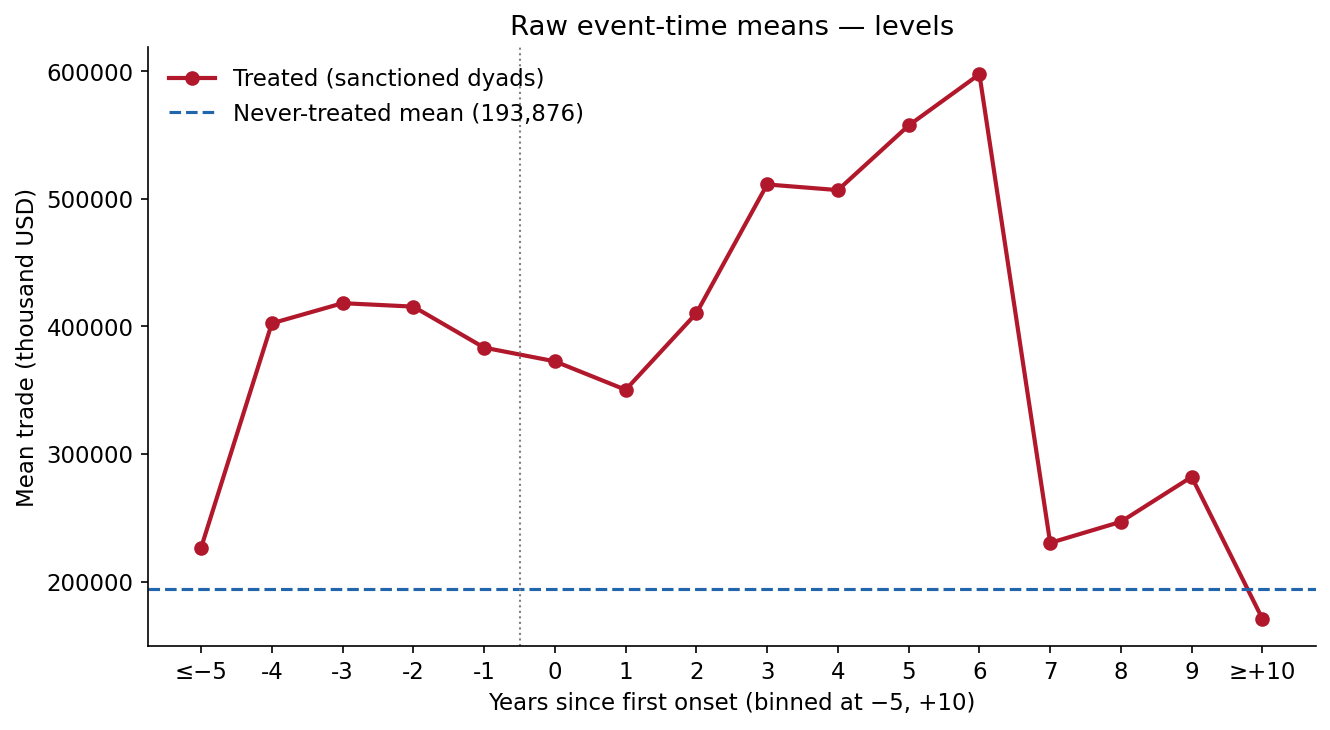

saved -> c_raw_means_levels.,pdf


In [ ]:
FIG_PATH = '/content/drive/MyDrive/IMT_studies/Applied_econ/Project/Figures/'
import os; os.makedirs(FIG_PATH, exist_ok=True)

# publication defaults
plt.rcParams.update({
    "figure.dpi": 150,          # on-screen
    "savefig.dpi": 300,         # exported (article grade)
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

WINDOW = list(range(-5, 11))   # -5 .. +10

treated  = es[es["G"] > 0]
tr_mean  = treated.groupby("rel_bin")["trade"].mean().reindex(WINDOW)
control  = es[es["G"] == 0]
ctrl_mean = control["trade"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tr_mean.index, tr_mean.values, marker="o", lw=2,
        color="#b2182b", label="Treated (sanctioned dyads)")
ax.axhline(ctrl_mean, ls="--", color="#2166ac", lw=1.5,
           label=f"Never-treated mean ({ctrl_mean:,.0f})")
ax.axvline(-0.5, color="grey", lw=1, ls=":")

ax.set_xlabel("Years since first onset (binned at −5, +10)")
ax.set_ylabel("Mean trade (thousand USD)")
ax.set_title("Raw event-time means — levels")
ax.set_xticks(WINDOW)                              # one tick per event-time value
ax.set_xticklabels([f"≤−5" if k == -5 else f"≥+10" if k == 10 else str(k)
                    for k in WINDOW])              # label the bins honestly
ax.legend(frameon=False)
plt.tight_layout()

# fig.savefig(FIG_PATH + "c_raw_means_levels.png", bbox_inches="tight")
fig.savefig(FIG_PATH + "c_raw_means_levels.pdf", bbox_inches="tight")  # vector, for LaTeX
plt.show()
print("saved -> c_raw_means_levels.,pdf")

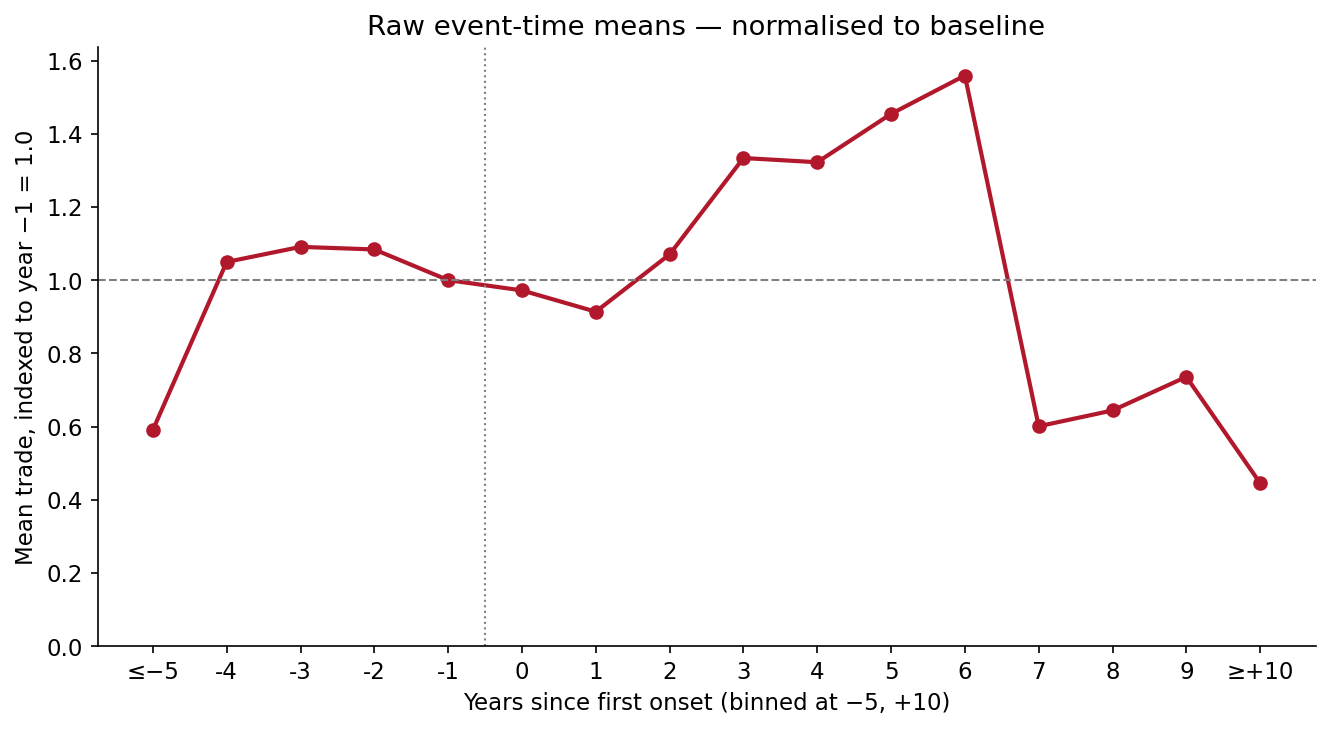

saved -> c_raw_means_normalised.pdf


In [ ]:
base    = tr_mean.loc[-1]
tr_norm = tr_mean / base

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tr_norm.index, tr_norm.values, marker="o", lw=2, color="#b2182b")
ax.axhline(1.0, color="grey", lw=1, ls="--")
ax.axvline(-0.5, color="grey", lw=1, ls=":")

ax.set_xlabel("Years since first onset (binned at −5, +10)")
ax.set_ylabel("Mean trade, indexed to year −1 = 1.0")
ax.set_title("Raw event-time means — normalised to baseline")
ax.set_xticks(WINDOW)
ax.set_xticklabels([f"≤−5" if k == -5 else f"≥+10" if k == 10 else str(k)
                    for k in WINDOW])
ax.set_ylim(0, max(1.2, tr_norm.max() * 1.05))
plt.tight_layout()

# fig.savefig(FIG_PATH + "c_raw_means_normalised.png", bbox_inches="tight")
fig.savefig(FIG_PATH + "c_raw_means_normalised.pdf", bbox_inches="tight")
plt.show()
print("saved -> c_raw_means_normalised.pdf")

Every feature that looks alarming — the pre-trend, the rise, the cliff — traces to the sample being a different set of dyads at every event time. That is precisely the disease the fixed-effects estimators cure. ETWFE and Callaway–Sant'Anna compare each dyad to itself and hold cohort composition fixed within each group-time cell. They don't average over a shifting population. That's the whole reason they exist.

## ETWFE-Poisson

Plain TWFE breaks in staggered designs because it implicitly uses already-treated dyads as controls for later-treated ones, and with heterogeneous effects those "forbidden comparisons" enter with negative weights that can flip the estimate's sign. Wooldridge's extended TWFE fixes this by saturating the model in cohort × period, so every effect is estimated against never-treated dyads only. We estimate it by Poisson pseudo-maximum-likelihood rather than OLS because trade is multiplicative and zero in ~51% of dyad-years — logs would drop the entire extensive margin, while Poisson keeps zeros and delivers clean semi-elasticities.

The estimator maximises the Poisson pseudo-likelihood

$$
\max_{\beta,\,\alpha,\,\gamma,\,\eta}\;\sum_{ijt}\Big\{ Y_{ijt}\,\mu_{ijt} - \exp(\mu_{ijt}) \Big\},
\qquad
\mu_{ijt} = \alpha_{it} + \gamma_{jt} + \eta_{ij} + \sum_{k=-5,\;k\neq-1}^{10} \beta_k\, D^k_{ijt}
$$

where $Y_{ijt}$ is bilateral trade in levels, $D^k_{ijt}=1$ if dyad $ij$ is $k$ years from its first onset (endpoints binned), and $\alpha_{it}$, $\gamma_{jt}$, $\eta_{ij}$ are exporter-year, importer-year and pair fixed effects. Each $\beta_k$ is a semi-elasticity relative to the omitted baseline year $k=-1$, so $100\,(e^{\beta_k}-1)$ is the percentage change in expected trade at event time $k$; standard errors are clustered by pair.

In [ ]:
# ---------------------------------------------------------------
# ESTIMATION FRAME
# Event-time dummies with k = -1 omitted (the baseline year).
# Never-treated dyads have all dummies = 0 -> they identify the
# year effects and serve as the clean control group.
# ---------------------------------------------------------------
est = es.copy()

# event-time dummy set: -5..+10, excluding the reference period -1
EVENT_K = [k for k in range(-5, 11) if k != -1]

for k in EVENT_K:
    # name them k_m5 ... k_p10 (minus/plus) -- formula-safe, no minus signs
    tag = f"m{abs(k)}" if k < 0 else f"p{k}"
    est[f"k_{tag}"] = ((est["G"] > 0) & (est["rel_bin"] == k)).astype(int)

dummy_cols = [f"k_{'m' + str(abs(k)) if k < 0 else 'p' + str(k)}" for k in EVENT_K]

# fixed-effect identifiers
est["exp_year"] = est["exp_iso3"] + "_" + est["year"].astype(str)
est["imp_year"] = est["imp_iso3"] + "_" + est["year"].astype(str)

print(f"estimation frame: {est.shape[0]:,} rows")
print(f"event-time dummies: {len(dummy_cols)} (k = -1 omitted as baseline)")
print(f"exporter-year FE levels: {est['exp_year'].nunique():,}")
print(f"importer-year FE levels: {est['imp_year'].nunique():,}")
print(f"pair FE levels:          {est['pair'].nunique():,}")
print(f"\ntreated obs by event time:")
print(est.loc[est['G'] > 0, 'rel_bin'].value_counts().sort_index().to_string())

estimation frame: 1,288,569 rows
event-time dummies: 15 (k = -1 omitted as baseline)
exporter-year FE levels: 6,055
importer-year FE levels: 6,055
pair FE levels:          52,435

treated obs by event time:
rel_bin
-5.0     33016
-4.0      3999
-3.0      4285
-2.0      4524
-1.0      4835
 0.0      4835
 1.0      4632
 2.0      3787
 3.0      3196
 4.0      2884
 5.0      2729
 6.0      2442
 7.0      1955
 8.0      1827
 9.0      1605
 10.0    11690


In [ ]:
# ---------------------------------------------------------------
# FEASIBILITY CHECK
# Total FE parameters absorbed + memory footprint. Run this before
# committing to the full estimation.
# ---------------------------------------------------------------
import psutil

n_fe = (est["exp_year"].nunique() + est["imp_year"].nunique()
        + est["pair"].nunique())
print(f"total FE levels to absorb: {n_fe:,}")
print(f"observations:              {est.shape[0]:,}")
print(f"obs per FE parameter:      {est.shape[0] / n_fe:.1f}")

mem = psutil.virtual_memory()
print(f"\nRAM available: {mem.available / 1e9:.1f} GB of {mem.total / 1e9:.1f} GB")

# trim to only the columns the estimation needs -- saves substantial memory
keep_cols = (["trade", "pair", "exp_year", "imp_year", "G", "rel_bin", "year"]
             + dummy_cols)
est = est[keep_cols].copy()
print(f"\ntrimmed frame: {est.shape} "
      f"({est.memory_usage(deep=True).sum() / 1e9:.2f} GB)")

total FE levels to absorb: 64,545
observations:              1,288,569
obs per FE parameter:      20.0

RAM available: 49.3 GB of 54.8 GB

trimmed frame: (1288569, 22) (0.43 GB)


#### Regression table

In [ ]:
%%time
# ---------------------------------------------------------------
# ETWFE-POISSON
#   trade ~ event-time dummies | exporter-year + importer-year + pair
#   SEs clustered by pair.
# ---------------------------------------------------------------
fml = f"trade ~ {' + '.join(dummy_cols)} | exp_year + imp_year + pair"
print(fml[:200], "...\n")

m_etwfe = pf.fepois(fml, data=est, vcov={"CRV1": "pair"})
print(m_etwfe.summary())

trade ~ k_m5 + k_m4 + k_m3 + k_m2 + k_p0 + k_p1 + k_p2 + k_p3 + k_p4 + k_p5 + k_p6 + k_p7 + k_p8 + k_p9 + k_p10 | exp_year + imp_year + pair ...



/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 6 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/models/fepois_.py:576: UserWarning: 361237 observations removed because of separation.
  warnings.warn(


###

Estimation:  Poisson
Dep. var.: trade, Fixed effects: exp_year + imp_year + pair
sample: None = all
Inference:  CRV1
Observations:  927326

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| k_m5          |      0.030 |        0.035 |     0.871 |      0.384 | -0.038 |   0.099 |
| k_m4          |      0.013 |        0.022 |     0.610 |      0.542 | -0.029 |   0.056 |
| k_m3          |      0.002 |        0.020 |     0.110 |      0.912 | -0.036 |   0.041 |
| k_m2          |      0.015 |        0.014 |     1.074 |      0.283 | -0.012 |   0.042 |
| k_p0          |     -0.064 |        0.015 |    -4.331 |      0.000 | -0.093 |  -0.035 |
| k_p1          |     -0.128 |        0.025 |    -5.151 |      0.000 | -0.177 |  -0.079 |
| k_p2          |     -0.137 |        0.029 |    -4.753 |      0.000 | -0.194 |  -0.081 |
| k_p3          |     -0.126 |        0.030 |

No pretrends recorded: from K_m5 to K_m2 are insignificant!

In [ ]:
res = m_etwfe.tidy()               # coefficient table as DataFrame
res.to_csv(DATA_PATH + "etwfe_onset_coefs.csv")
print(res)

             Estimate  Std. Error   t value      Pr(>|t|)      2.5%     97.5%
Coefficient                                                                  
k_m5         0.030353    0.034840  0.871210  3.836395e-01 -0.037932  0.098637
k_m4         0.013331    0.021851  0.610089  5.418027e-01 -0.029496  0.056158
k_m3         0.002160    0.019614  0.110136  9.123014e-01 -0.036282  0.040602
k_m2         0.014878    0.013847  1.074478  2.826085e-01 -0.012261  0.042017
k_p0        -0.064240    0.014832 -4.331178  1.483140e-05 -0.093310 -0.035170
k_p1        -0.127873    0.024826 -5.150702  2.595132e-07 -0.176532 -0.079215
k_p2        -0.137279    0.028883 -4.752891  2.005283e-06 -0.193889 -0.080669
k_p3        -0.126263    0.030108 -4.193687  2.744569e-05 -0.185274 -0.067253
k_p4        -0.160487    0.033634 -4.771617  1.827532e-06 -0.226408 -0.094566
k_p5        -0.181006    0.035757 -5.062168  4.145148e-07 -0.251087 -0.110924
k_p6        -0.189086    0.045842 -4.124736  3.711606e-05 -0.278

Separation. Poisson estimation removes 361,237 observations (28%) belonging to dyads with zero recorded trade in every observed year: the pair fixed effect perfectly predicts their zero outcome, so they are dropped automatically (Correia, Guimarães & Zylkin 2019) and carry no information on the intensive-margin effect. This is correct rather than a loss — the estimate is identified off pairs that have a trade relationship to change, and the always-zero pairs represent an extensive margin analysed separately in Notebook 4.

In [ ]:
# ---------------------------------------------------------------
# LaTeX TABLE: ETWFE-Poisson onset event-study coefficients
# Emits a booktabs table to Figures/ and prints it inline.
# ---------------------------------------------------------------
res = m_etwfe.tidy()   # columns: Estimate, Std. Error, t value, Pr(>|t|), 2.5%, 97.5%

# map internal names -> event-time labels
def k_label(name):
    tag = name.replace("k_", "")
    k = -int(tag[1:]) if tag.startswith("m") else int(tag[1:])
    if k == -5:  return r"$\leq -5$"
    if k == 10:  return r"$\geq +10$"
    return f"${k:+d}$"

tab = res.copy()
tab["k"]      = [k_label(n) for n in tab.index]
tab["semi"]   = 100 * (np.exp(tab["Estimate"]) - 1)     # % effect
tab["stars"]  = pd.cut(tab["Pr(>|t|)"], [-1, .01, .05, .1, 1],
                       labels=["***", "**", "*", ""]).astype(str)

# insert the omitted baseline row at k = -1
base = pd.DataFrame({"k": ["$-1$ (ref.)"], "Estimate": [np.nan]})

def fmt(r):
    if pd.isna(r["Estimate"]):
        return f"{r['k']} & --- & --- & --- \\\\"
    return (f"{r['k']} & {r['Estimate']:.3f}{r['stars']} "
            f"& ({r['Std. Error']:.3f}) & {r['semi']:+.1f}\\% \\\\")

order = ["k_m5","k_m4","k_m3","k_m2"]  # leads
order += ["__ref__"]                   # baseline slot
order += ["k_p0","k_p1","k_p2","k_p3","k_p4","k_p5",
          "k_p6","k_p7","k_p8","k_p9","k_p10"]  # lags

lines = []
for name in order:
    if name == "__ref__":
        lines.append(r"$-1$ (ref.) & --- & --- & --- \\")
        lines.append(r"\midrule")
    else:
        lines.append(fmt(tab.loc[name]))

body = "\n".join(lines)

latex = r"""\begin{table}[htbp]
\centering
\caption{Effect of sanction onset on bilateral trade (ETWFE--Poisson)}
\label{tab:etwfe_onset}
\begin{tabular}{lccc}
\toprule
Event time $k$ & $\beta_k$ & (Cluster SE) & \% effect \\
\midrule
""" + body + r"""
\bottomrule
\end{tabular}
\begin{minipage}{0.82\textwidth}
\vspace{4pt}
\footnotesize
\textit{Notes.} Poisson pseudo-maximum-likelihood with exporter-year,
importer-year and pair fixed effects; standard errors clustered by dyad.
$N = """ + f"{int(m_etwfe._N):,}".replace(",", r"{,}") + r"""$ after separation.
$\beta_k$ is the coefficient on the event-time indicator relative to $k=-1$;
\% effect $= 100(e^{\beta_k}-1)$. Endpoints binned ($\leq-5$, $\geq+10$).
$^{*}p<0.10$, $^{**}p<0.05$, $^{***}p<0.01$.
\end{minipage}
\end{table}"""

print(latex)

\begin{table}[htbp]
\centering
\caption{Effect of sanction onset on bilateral trade (ETWFE--Poisson)}
\label{tab:etwfe_onset}
\begin{tabular}{lccc}
\toprule
Event time $k$ & $\beta_k$ & (Cluster SE) & \% effect \\
\midrule
$\leq -5$ & 0.030 & (0.035) & +3.1\% \\
$-4$ & 0.013 & (0.022) & +1.3\% \\
$-3$ & 0.002 & (0.020) & +0.2\% \\
$-2$ & 0.015 & (0.014) & +1.5\% \\
$-1$ (ref.) & --- & --- & --- \\
\midrule
$+0$ & -0.064*** & (0.015) & -6.2\% \\
$+1$ & -0.128*** & (0.025) & -12.0\% \\
$+2$ & -0.137*** & (0.029) & -12.8\% \\
$+3$ & -0.126*** & (0.030) & -11.9\% \\
$+4$ & -0.160*** & (0.034) & -14.8\% \\
$+5$ & -0.181*** & (0.036) & -16.6\% \\
$+6$ & -0.189*** & (0.046) & -17.2\% \\
$+7$ & -0.201*** & (0.042) & -18.2\% \\
$+8$ & -0.187*** & (0.039) & -17.0\% \\
$+9$ & -0.127** & (0.056) & -11.9\% \\
$\geq +10$ & -0.101 & (0.066) & -9.6\% \\
\bottomrule
\end{tabular}
\begin{minipage}{0.82\textwidth}
\vspace{4pt}
\footnotesize
\textit{Notes.} Poisson pseudo-maximum-likelihood with exporter-

#### Pre-trend test

In [ ]:
# ---------------------------------------------------------------
# JOINT PRE-TREND TEST
# Wald test that all leads are jointly zero. Failure to reject =>
# parallel trends holds, treated and control move together pre-onset.
# ---------------------------------------------------------------
b     = m_etwfe.coef()          # coefficient Series
leads = ["k_m5", "k_m4", "k_m3", "k_m2"]

# stored clustered covariance -> align to a DataFrame indexed by coef names
V = pd.DataFrame(m_etwfe._vcov, index=b.index, columns=b.index)

bl = b.loc[leads].values
Vl = V.loc[leads, leads].values
q  = len(leads)

W  = float(bl @ np.linalg.inv(Vl) @ bl)   # Wald statistic ~ chi2(q)
p  = 1 - stats.chi2.cdf(W, q)

print(f"joint pre-trend test  H0: {' = '.join(leads)} = 0")
print(f"  Wald chi2({q}) = {W:.3f}")
print(f"  p-value        = {p:.3f}")
print("  => " + ("FAIL TO REJECT: pre-trends flat, parallel trends holds"
                 if p > 0.10 else
                 "REJECT: pre-trend present, design compromised"))

joint pre-trend test  H0: k_m5 = k_m4 = k_m3 = k_m2 = 0
  Wald chi2(4) = 2.545
  p-value        = 0.637
  => FAIL TO REJECT: pre-trends flat, parallel trends holds


In [ ]:
# ---------------------------------------------------------------
# LaTeX TABLE: joint pre-trend Wald test
# ---------------------------------------------------------------
wald_latex = r"""\begin{table}[htbp]
\centering
\caption{Joint pre-trend test (parallel trends)}
\label{tab:etwfe_pretrend}
\begin{tabular}{lc}
\toprule
 & Value \\
\midrule
Null hypothesis & $\beta_{-5}=\beta_{-4}=\beta_{-3}=\beta_{-2}=0$ \\
Wald statistic  & $\chi^2(""" + f"{q}" + r""") = """ + f"{W:.3f}" + r"""$ \\
$p$-value       & $""" + f"{p:.3f}" + r"""$ \\
Decision        & Fail to reject at 10\% \\
\bottomrule
\end{tabular}
\begin{minipage}{0.72\textwidth}
\vspace{4pt}
\footnotesize
\textit{Notes.} Wald test that the four pre-onset leads are jointly zero,
using the dyad-clustered covariance matrix. Failure to reject supports the
parallel-trends assumption underlying the event-study design.
\end{minipage}
\end{table}"""

print(wald_latex)

\begin{table}[htbp]
\centering
\caption{Joint pre-trend test (parallel trends)}
\label{tab:etwfe_pretrend}
\begin{tabular}{lc}
\toprule
 & Value \\
\midrule
Null hypothesis & $\beta_{-5}=\beta_{-4}=\beta_{-3}=\beta_{-2}=0$ \\
Wald statistic  & $\chi^2(4) = 2.545$ \\
$p$-value       & $0.637$ \\
Decision        & Fail to reject at 10\% \\
\bottomrule
\end{tabular}
\begin{minipage}{0.72\textwidth}
\vspace{4pt}
\footnotesize
\textit{Notes.} Wald test that the four pre-onset leads are jointly zero,
using the dyad-clustered covariance matrix. Failure to reject supports the
parallel-trends assumption underlying the event-study design.
\end{minipage}
\end{table}


#### Plot

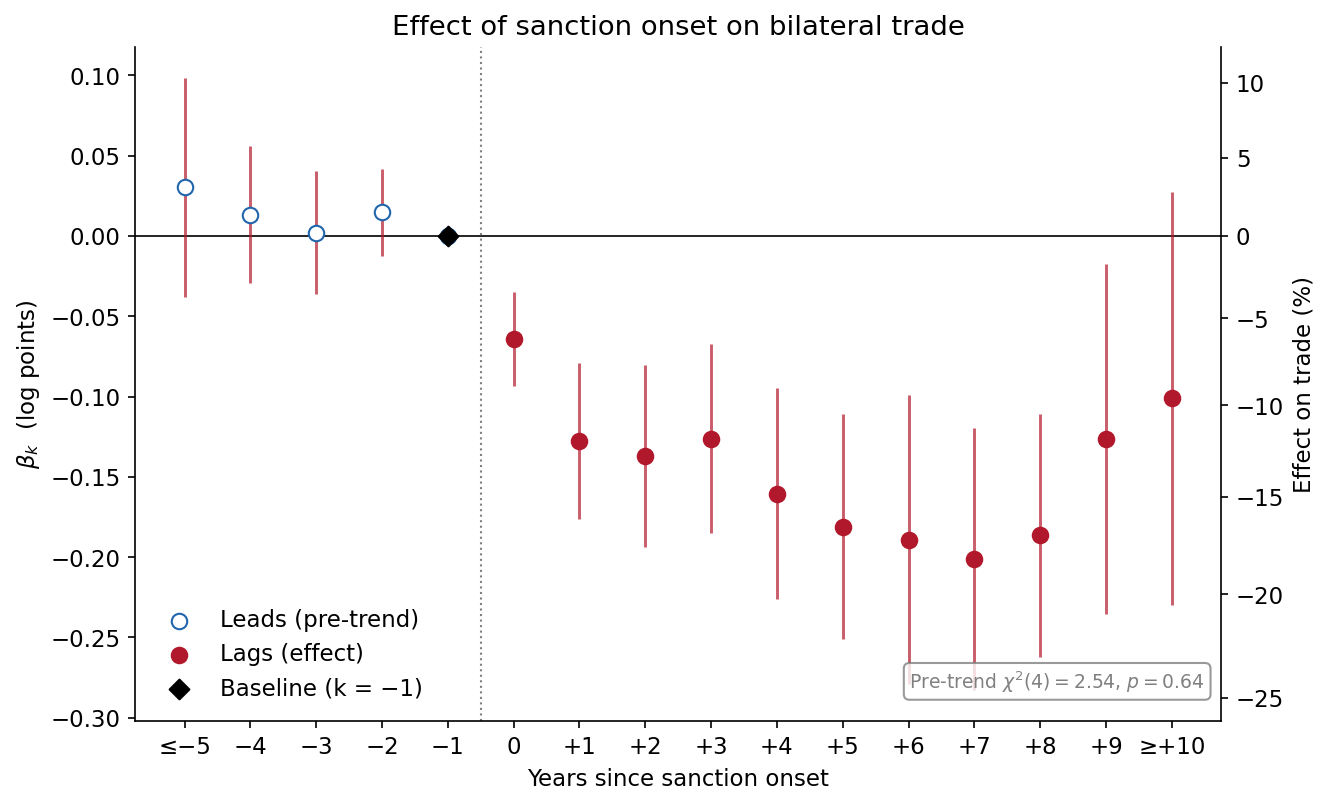

saved -> f_event_study_onset.pdf


In [ ]:
# ---------------------------------------------------------------
# EVENT-STUDY PLOT — ETWFE-Poisson onset dynamics
# Coefficients with 95% dyad-clustered CIs, baseline k=-1 pinned at 0.
# Leads (left of 0) test parallel trends; lags (right) are the effect.
# ---------------------------------------------------------------
res = m_etwfe.tidy()

# recover event time k from each coefficient name
def name_to_k(name):
    tag = name.replace("k_", "")
    return -int(tag[1:]) if tag.startswith("m") else int(tag[1:])

res = res.assign(k=[name_to_k(n) for n in res.index]).sort_values("k")

# insert the omitted baseline as an explicit zero at k = -1
base_row = pd.DataFrame({"Estimate": [0.0], "2.5%": [0.0], "97.5%": [0.0], "k": [-1]})
plotd = pd.concat([res[["Estimate", "2.5%", "97.5%", "k"]], base_row]) \
          .sort_values("k").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5.5))

# zero line and onset marker
ax.axhline(0, color="black", lw=0.8)
ax.axvline(-0.5, color="grey", lw=1, ls=":")   # sits between the last lead and onset

# split leads / baseline / lags for colouring
is_lead = plotd["k"] < 0
is_lag  = plotd["k"] >= 0

# confidence bands (vertical whiskers)
ax.vlines(plotd["k"], plotd["2.5%"], plotd["97.5%"],
          color="#b2182b", lw=1.4, alpha=0.7)

# point estimates: leads hollow, lags filled, baseline marked
ax.scatter(plotd.loc[is_lead, "k"], plotd.loc[is_lead, "Estimate"],
           facecolors="white", edgecolors="#2166ac", s=55, zorder=3, label="Leads (pre-trend)")
ax.scatter(plotd.loc[is_lag, "k"], plotd.loc[is_lag, "Estimate"],
           color="#b2182b", s=55, zorder=3, label="Lags (effect)")
ax.scatter([-1], [0], color="black", marker="D", s=45, zorder=4, label="Baseline (k = −1)")

# right axis in % terms so the reader gets magnitude without exponentiating
def to_pct(beta): return 100 * (np.exp(beta) - 1)
secax = ax.secondary_yaxis("right",
        functions=(lambda b: 100*(np.exp(b)-1), lambda p: np.log1p(p/100)))
secax.set_ylabel("Effect on trade (%)")

ax.set_xlabel("Years since sanction onset")
ax.set_ylabel(r"$\beta_k$  (log points)")
ax.set_title("Effect of sanction onset on bilateral trade")
ax.set_xticks(range(-5, 11))
ax.set_xticklabels(["≤−5","−4","−3","−2","−1","0","+1","+2","+3","+4",
                    "+5","+6","+7","+8","+9","≥+10"])
ax.legend(frameon=False, loc="lower left")

# annotate the joint pre-trend test result on the figure itself
ax.text(0.985, 0.04,
        f"Pre-trend $\\chi^2(4)={W:.2f}$, $p={p:.2f}$",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=9, color="grey",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.8))

plt.tight_layout()
fig.savefig(FIG_PATH + "f_event_study_onset.pdf", bbox_inches="tight")
plt.show()
print("saved -> f_event_study_onset.pdf")

## Callaway–Sant'Anna

 ETWFE saturates one regression with cohort × period interactions; Callaway–Sant'Anna attacks the same staggered-treatment problem from the opposite direction. Rather than fit a single model, it estimates a separate effect for every (cohort, period) cell — the *group-time ATT* — by comparing each cohort's before-to-after change in the outcome against the never-treated group's change over the same calendar years, then aggregates these cells into an event-study path. Because every building block compares a treated cohort only to never-treated dyads, no already-treated dyad is ever used as a control, so the forbidden-comparison problem is excluded by construction rather than by saturation. It serves here as a cross-check: a different estimator, resting on different assumptions, reproducing the ETWFE shape is far stronger evidence than either alone. The `did` implementation is linear, so — unlike the Poisson workhorse — it runs on $\log(\text{trade})$ over positive flows and speaks only to the intensive margin (trading pairs); the extensive margin remains with Poisson here and with the linear-probability model of Notebook 4.

**What the computer solves.** For onset-cohort $g$ (dyads first sanctioned in year $g$) and calendar year $t$, the group-time average treatment effect is

$$
ATT(g,t) \;=\; \mathbb{E}\!\left[\big(Y_{t} - Y_{g-1}\big) \;\middle|\; G = g\right] \;-\; \mathbb{E}\!\left[\big(Y_{t} - Y_{g-1}\big) \;\middle|\; \text{never treated}\right],
$$

the treated cohort's change in $\log(\text{trade})$ from the year before onset ($g-1$) to year $t$, net of the never-treated group's change over the same span. The event-study coefficient at horizon $k$ aggregates these cells across cohorts observed at that horizon,

$$
\theta(k) \;=\; \sum_{g} \mathbb{P}(G = g \mid \text{observed at horizon } k)\; ATT(g,\, g+k),
$$

weighting each cohort by its share of the dyads observed $k$ years from onset. Standard errors are from the influence-function bootstrap clustered by dyad; leads ($k<0$) test parallel trends, lags ($k\ge0$) give the dynamic effect, both directly comparable to the ETWFE path.

In [ ]:
# ---------------------------------------------------------------
# CS SAMPLE: intensive margin, log(trade) on positive flows
#   unit  = numeric dyad id
#   G     = onset cohort year (0 = never-treated)
#   tname = calendar year
# ---------------------------------------------------------------
cs = es[["pair", "year", "trade", "G"]].copy()

# intensive margin: positive flows only
before = cs.shape[0]
cs = cs[cs["trade"] > 0].copy()
print(f"positive-flow rows: {cs.shape[0]:,} ({before - cs.shape[0]:,} zeros dropped)")

cs["ltrade"] = np.log(cs["trade"])

# CS requires an integer unit id
cs["id"] = cs["pair"].astype("category").cat.codes + 1

# CS requires a BALANCED-in-id panel? No -- did handles unbalanced,
# but each unit needs >= 2 periods. Drop singletons.
n_per = cs.groupby("id")["year"].transform("count")
cs = cs[n_per >= 2].copy()

# G is already 0 for never-treated, onset-year for treated
cs["G"] = cs["G"].astype(int)

print(f"\nCS frame: {cs.shape[0]:,} rows, {cs['id'].nunique():,} dyads")
print(f"treated dyads: {cs.loc[cs['G']>0,'id'].nunique():,}")
print(f"never-treated: {cs.loc[cs['G']==0,'id'].nunique():,}")
print(f"cohorts: {sorted(cs.loc[cs['G']>0,'G'].unique())}")

positive-flow rows: 608,945 (679,624 zeros dropped)

CS frame: 606,516 rows, 37,536 dyads
treated dyads: 3,925
never-treated: 33,611
cohorts: [np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [ ]:
import rpy2
%load_ext rpy2.ipython
print("rpy2 loaded")

rpy2 loaded


In [ ]:
# hand the CS frame to R
%R -i cs
print("cs pushed to R:", cs.shape)

cs pushed to R: (606516, 6)


### Log(trade)

In [ ]:
%%R
options(repos = c(CRAN = "https://packagemanager.posit.co/cran/__linux__/jammy/latest"))
if (!requireNamespace("remotes", quietly = TRUE)) install.packages("remotes")

if (!requireNamespace("did", quietly = TRUE) ||
    packageVersion("did") != "2.5.1") {
  remotes::install_version("did", version = "2.5.1", upgrade = "never")
}
library(did)
cat("did version:", as.character(packageVersion("did")), "\n")

did version: 2.5.1 


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/remotes_2.5.0.tar.gz'
Content type 'binary/octet-stream' length 165146 bytes (161 KB)
downloaded 161 KB


The downloaded source packages are in
	‘/tmp/Rtmp4oYJaq/downloaded_packages’
Installing 13 packages: BH, bigmemory.sri, RcppEigen, Formula, bigmemory, RcppArmadillo, stringmagic, fastglm, BMisc, trust, dreamerr, DRDID, pbapply
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/BH_1.90.0-1.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/bigmemory.sri_0.1.8.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/RcppEigen_0.3.4.0.2.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/Formul

In [ ]:
%%R -o cs_dyn -o cs_es_tab
suppressMessages(library(did))

# ---------------------------------------------------------------
# CALLAWAY-SANT'ANNA via did::att_gt
# outcome = log(trade), never-treated controls, dyad-clustered
# doubly-robust (default), universal base period for clean pre-trends
# ---------------------------------------------------------------

set.seed(42)

att <- att_gt(
  yname    = "ltrade",
  tname    = "year",
  idname   = "id",
  gname    = "G",
  data     = cs,
  control_group = "nevertreated",
  est_method    = "dr",          # doubly-robust
  base_period   = "universal",   # all pre-periods vs fixed baseline -> clean leads
  bstrap        = TRUE,          # influence-function multiplier bootstrap
  cband         = FALSE,         # pointwise CIs (faster; we test leads jointly ourselves)
  clustervars   = "id",
  allow_unbalanced_panel = TRUE
)

# aggregate group-time ATTs into an event-study path
dyn <- aggte(att, type = "dynamic", min_e = -5, max_e = 10, na.rm = TRUE)

# extract the event-study table for Python
cs_es_tab <- data.frame(
  e   = dyn$egt,
  att = dyn$att.egt,
  se  = dyn$se.egt
)
cs_dyn <- data.frame(
  overall_att = dyn$overall.att,
  overall_se  = dyn$overall.se
)

print(summary(dyn))


Call:
aggte(MP = att, type = "dynamic", min_e = -5, max_e = 10, na.rm = TRUE)

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


Overall summary of ATT's based on event-study/dynamic aggregation:  
   ATT    Std. Error     [ 95%  Conf. Int.] 
 0.081        0.0773    -0.0706      0.2325 


Dynamic Effects:
 Event time Estimate Std. Error [95% Pointwise  Conf. Band]  
         -5  -0.3089     0.0585         -0.4235     -0.1944 *
         -4  -0.1255     0.0550         -0.2332     -0.0178 *
         -3  -0.1602     0.0531         -0.2641     -0.0562 *
         -2  -0.1051     0.0479         -0.1991     -0.0112 *
         -1   0.0000         NA              NA          NA  
          0  -0.1631     0.0509         -0.2628     -0.0633 *
          1  -0.2083     0.0579         -0.3218 

You have an unbalanced panel. Proceeding as such.
In addition: There were 16 warnings (use warnings() to see them)


Pre-trends. Possible reason - half of observations are zero and are dropped to assume the log scale for intensive margin.

In [ ]:
# ---------------------------------------------------------------
# LaTeX: CS event-study on log(trade), positive flows
# Documented-failure table -- the significant leads are the finding.
# cs_es_tab holds the dynamic aggregation (from the log run).
# ---------------------------------------------------------------
def cs_latex(tab, caption, label, outcome_note):
    t = tab.copy().sort_values("e")
    t["sig"] = np.where(
        (t["att"] - 1.96*t["se"]) * (t["att"] + 1.96*t["se"]) > 0, "*", "")
    rows = []
    for _, r in t.iterrows():
        if r["e"] == -1:
            rows.append(r"$-1$ (ref.) & --- & --- \\")
            rows.append(r"\midrule")
        else:
            k = f"${int(r['e']):+d}$"
            rows.append(f"{k} & {r['att']:.3f}{r['sig']} & ({r['se']:.3f}) \\\\")
    body = "\n".join(rows)
    return (
r"""\begin{table}[htbp]
\centering
\caption{""" + caption + r"""}
\label{""" + label + r"""}
\begin{tabular}{lcc}
\toprule
Event time $k$ & $\widehat{ATT}(k)$ & (Cluster SE) \\
\midrule
""" + body + r"""
\bottomrule
\end{tabular}
\begin{minipage}{0.80\textwidth}
\vspace{4pt}
\footnotesize
\textit{Notes.} Callaway--Sant'Anna (2021) doubly-robust estimator, """ + outcome_note + r""",
never-treated controls, universal base period, dyad-clustered influence-function
bootstrap. $^{*}$ 95\% pointwise interval excludes zero. The significant pre-onset
leads ($k<0$) indicate a violation of parallel trends on this sample; see text.
\end{minipage}
\end{table}""")

print(cs_latex(
    cs_es_tab,
    r"Callaway--Sant'Anna cross-check, $\log(\text{trade})$ on positive flows",
    "tab:cs_log",
    r"outcome $\log(\text{trade})$ restricted to positive flows"))

\begin{table}[htbp]
\centering
\caption{Callaway--Sant'Anna cross-check, $\log(\text{trade})$ on positive flows}
\label{tab:cs_log}
\begin{tabular}{lcc}
\toprule
Event time $k$ & $\widehat{ATT}(k)$ & (Cluster SE) \\
\midrule
$-5$ & -0.309* & (0.058) \\
$-4$ & -0.125* & (0.055) \\
$-3$ & -0.160* & (0.053) \\
$-2$ & -0.105* & (0.048) \\
$-1$ (ref.) & --- & --- \\
\midrule
$+0$ & -0.163* & (0.051) \\
$+1$ & -0.208* & (0.058) \\
$+2$ & -0.051 & (0.066) \\
$+3$ & -0.269* & (0.083) \\
$+4$ & -0.035 & (0.094) \\
$+5$ & 0.119 & (0.102) \\
$+6$ & 0.191 & (0.118) \\
$+7$ & 0.303* & (0.130) \\
$+8$ & 0.241 & (0.156) \\
$+9$ & 0.331* & (0.153) \\
$+10$ & 0.433* & (0.153) \\
\bottomrule
\end{tabular}
\begin{minipage}{0.80\textwidth}
\vspace{4pt}
\footnotesize
\textit{Notes.} Callaway--Sant'Anna (2021) doubly-robust estimator, outcome $\log(\text{trade})$ restricted to positive flows,
never-treated controls, universal base period, dyad-clustered influence-function
bootstrap. $^{*}$ 95\% pointwise in

### Asinh(trade)
Allows to keep all the zeros.

In [ ]:
# ---------------------------------------------------------------
# CS SAMPLE v2: asinh(trade), keeping zeros
# asinh(x) = log(x + sqrt(x^2 + 1)); defined at 0, so the trade-to-zero
# dyads STAY in the sample instead of selectively exiting. This is what
# should remove the spurious pre-trend the log-on-positives sample showed.
# ---------------------------------------------------------------
cs2 = es[["pair", "year", "trade", "G"]].copy()

cs2["atrade"] = np.arcsinh(cs2["trade"])      # keeps zeros: asinh(0) = 0
cs2["id"]     = cs2["pair"].astype("category").cat.codes + 1
cs2["G"]      = cs2["G"].astype(int)

# each unit needs >= 2 periods (all do, but guard anyway)
n_per = cs2.groupby("id")["year"].transform("count")
cs2 = cs2[n_per >= 2].copy()

print(f"CS-asinh frame: {cs2.shape[0]:,} rows, {cs2['id'].nunique():,} dyads")
print(f"treated: {cs2.loc[cs2['G']>0,'id'].nunique():,}  "
      f"never-treated: {cs2.loc[cs2['G']==0,'id'].nunique():,}")
print(f"zero-trade rows retained: {(cs2['trade']==0).sum():,}")
print(f"cohorts: {cs2.loc[cs2['G']>0,'G'].nunique()}")

CS-asinh frame: 1,288,563 rows, 52,429 dyads
treated: 4,835  never-treated: 47,594
zero-trade rows retained: 679,618
cohorts: 25


In [ ]:
%R -i cs2
print("cs2 pushed to R:", cs2.shape)

cs2 pushed to R: (1288563, 6)


In [ ]:
%%R -o cs2_es_tab -o cs2_dyn
suppressMessages(library(did))

set.seed(42)

att2 <- att_gt(
  yname    = "atrade",
  tname    = "year",
  idname   = "id",
  gname    = "G",
  data     = cs2,
  control_group = "nevertreated",
  est_method    = "dr",
  base_period   = "universal",
  bstrap        = TRUE,
  cband         = FALSE,
  clustervars   = "id",
  allow_unbalanced_panel = TRUE
)

dyn2 <- aggte(att2, type = "dynamic", min_e = -5, max_e = 10, na.rm = TRUE)

cs2_es_tab <- data.frame(
  e   = dyn2$egt,
  att = dyn2$att.egt,
  se  = dyn2$se.egt
)
cs2_dyn <- data.frame(
  overall_att = dyn2$overall.att,
  overall_se  = dyn2$overall.se
)

print(summary(dyn2))


Call:
aggte(MP = att2, type = "dynamic", min_e = -5, max_e = 10, na.rm = TRUE)

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


Overall summary of ATT's based on event-study/dynamic aggregation:  
    ATT    Std. Error     [ 95%  Conf. Int.] 
 0.1274        0.1409    -0.1488      0.4035 


Dynamic Effects:
 Event time Estimate Std. Error [95% Pointwise  Conf. Band]  
         -5   0.2337     0.0560          0.1239      0.3436 *
         -4  -0.1019     0.0395         -0.1794     -0.0244 *
         -3  -0.1889     0.0371         -0.2617     -0.1162 *
         -2  -0.0158     0.0326         -0.0797      0.0481  
         -1   0.0000         NA              NA          NA  
          0   0.1501     0.0366          0.0783      0.2219 *
          1   0.1557     0.0418          0.07

You have an unbalanced panel. Proceeding as such.
In addition: Warning messages:
1: In did_standardization(data, args) :
  Some groups in your dataset have very few observations, which may cause estimation problems.
  Check groups: 2018,2016.
2: In run_DRDID(cohort_data, covariates, dp2, g_val = dp2$treated_groups[g],  :
  No units in group 2010 in time period 2019
3: In run_DRDID(cohort_data, covariates, dp2, g_val = dp2$treated_groups[g],  :
  No units in group 2010 in time period 2020
4: In run_DRDID(cohort_data, covariates, dp2, g_val = dp2$treated_groups[g],  :
  No units in group 2016 in time period 2018
5: In run_DRDID(cohort_data, covariates, dp2, g_val = dp2$treated_groups[g],  :
  No units in group 2016 in time period 2019
6: In run_DRDID(cohort_data, covariates, dp2, g_val = dp2$treated_groups[g],  :
  No units in group 2016 in time period 2020
7: In att_gt(yname = "atrade", tname = "year", idname = "id", gname = "G",  :
  Not returning pre-test Wald statistic due to singula

Leads are still a mess.

A Callaway–Sant'Anna cross-check was attempted on both log(trade) (positive flows) and asinh(trade). The former shows significant negative pre-trends driven by sample selection — dropping the ~53% of dyad-years with zero trade removes precisely the sanctioned dyads pushed to zero. The latter retains zeros but produces degenerate cohort×period cells (singular covariance, empty small cohorts), because the group-time estimator requires adequately-populated, positive-variance cells that a half-zero finely-staggered panel does not provide. Both failures reflect the same feature — pervasive zeros in a staggered gravity panel — and motivate estimators that pool the data and model zeros directly (ETWFE-Poisson) rather than differencing many small cohort cells.

In [ ]:
# ---------------------------------------------------------------
# LaTeX: CS event-study on asinh(trade), full sample
# cs2_es_tab holds the asinh dynamic aggregation.
# ---------------------------------------------------------------
print(cs_latex(
    cs2_es_tab,
    r"Callaway--Sant'Anna cross-check, $\operatorname{asinh}(\text{trade})$, full sample",
    "tab:cs_asinh",
    r"outcome $\operatorname{asinh}(\text{trade})$ retaining zeros"))

\begin{table}[htbp]
\centering
\caption{Callaway--Sant'Anna cross-check, $\operatorname{asinh}(\text{trade})$, full sample}
\label{tab:cs_asinh}
\begin{tabular}{lcc}
\toprule
Event time $k$ & $\widehat{ATT}(k)$ & (Cluster SE) \\
\midrule
$-5$ & 0.234* & (0.056) \\
$-4$ & -0.102* & (0.040) \\
$-3$ & -0.189* & (0.037) \\
$-2$ & -0.016 & (0.033) \\
$-1$ (ref.) & --- & --- \\
\midrule
$+0$ & 0.150* & (0.037) \\
$+1$ & 0.156* & (0.042) \\
$+2$ & 0.085 & (0.088) \\
$+3$ & -0.121 & (0.089) \\
$+4$ & -0.101 & (0.164) \\
$+5$ & 0.166 & (0.173) \\
$+6$ & 0.039 & (0.178) \\
$+7$ & 0.070 & (0.217) \\
$+8$ & 0.208 & (0.217) \\
$+9$ & 0.274 & (0.284) \\
$+10$ & 0.475 & (0.295) \\
\bottomrule
\end{tabular}
\begin{minipage}{0.80\textwidth}
\vspace{4pt}
\footnotesize
\textit{Notes.} Callaway--Sant'Anna (2021) doubly-robust estimator, outcome $\operatorname{asinh}(\text{trade})$ retaining zeros,
never-treated controls, universal base period, dyad-clustered influence-function
bootstrap. $^{*}$ 95\% point

## de Chaisemartin–D'Haultfœuille
 — zero-preserving cross-check


(de Chaisemartin, C., & D'Haultfœuille, X. (2020). "Two-Way Fixed Effects Estimators with Heterogeneous Treatment Effects." American Economic Review, 110(9), 2964–2996.)


Callaway–Sant'Anna failed here because it slices the panel into hundreds of cohort × period cells, and a half-zero, finely-staggered gravity panel leaves many of those cells too thin or too low-variance to estimate. de Chaisemartin–D'Haultfœuille avoids this by building far fewer, larger blocks: in each period it compares the outcome change of dyads whose treatment *just switched* against the change of dyads whose treatment *did not change*, then averages these comparisons across periods into a dynamic path. Because it differences the outcome in levels rather than taking logs, it keeps all zeros and runs on the full sample — the two things that broke the CS cross-check. Its defining feature is that it is built for treatments that switch **on and off**, which makes it both the right zero-preserving cross-check for onset here and the natural workhorse for the termination analysis in Notebook 3. Like CS it is linear, so it corroborates the *shape and sign* of the ETWFE–Poisson path rather than reproducing its semi-elasticities; ETWFE–Poisson remains the estimator whose magnitudes we quote.

**What the computer solves.** For each pair of adjacent periods $t-1 \to t$, dyads are split by whether their treatment status changed. The dynamic effect at horizon $\ell$ aggregates, across all periods, the difference between switchers' and non-switchers' outcome changes measured $\ell$ periods after a switch:

$$
\widehat{\delta}_\ell \;=\; \sum_{t}\; w_t\,\Big[\big(Y_{t+\ell} - Y_{t-1}\big)_{\text{switchers at } t} \;-\; \big(Y_{t+\ell} - Y_{t-1}\big)_{\text{stable at } t}\Big],
$$

where switchers at $t$ are dyads that move from untreated to treated (for onset), stable dyads are those whose status is unchanged, and the weights $w_t$ are proportional to the number of switchers in each period. The estimator also computes **placebo** effects $\widehat{\delta}_{-\ell}$ before the switch, which play the role of the pre-trend leads: under parallel trends they should be zero. Standard errors are from a dyad-clustered bootstrap; the placebos test the design and the post-switch $\widehat{\delta}_\ell$ give the dynamic effect, both directly comparable to the ETWFE event-study path.

Environment note. The cell below installs a JDK and registers it with the system linker so R's rJava can load. This runs once per session; no restart required.

In [ ]:
import os, glob, subprocess
# === dCDH environment setup: Java for rJava ===

!apt-get install -y default-jdk -q > /dev/null 2>&1

jvm_dir   = os.path.dirname(glob.glob("/usr/lib/jvm/**/libjvm.so", recursive=True)[0])
java_home = jvm_dir.rsplit("/lib/", 1)[0]

# Register the JVM with the SYSTEM linker. This is the step that matters:
# LD_LIBRARY_PATH is read when a process launches, so it cannot be set for an
# already-running R session. ldconfig updates the cache dyn.load reads at call time.
with open("/etc/ld.so.conf.d/jvm.conf", "w") as f:
    f.write(jvm_dir + "\n")
subprocess.run(["ldconfig"], check=True)

os.environ["JAVA_HOME"] = java_home
print("JAVA_HOME =", java_home)
print("linker registered:", jvm_dir)

JAVA_HOME = /usr/lib/jvm/java-21-openjdk-amd64
linker registered: /usr/lib/jvm/java-21-openjdk-amd64/lib/server


In [ ]:
import rpy2
%load_ext rpy2.ipython
print("rpy2 loaded")

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
rpy2 loaded


In [ ]:
%%R
# Pin the pre-polars version. 2.4.0+ requires the polars R package (Rust),
# which cannot compile in Colab; 1.0.15 is the last release before that.
if (!requireNamespace("remotes", quietly = TRUE)) install.packages("remotes")

if (!requireNamespace("DIDmultiplegtDYN", quietly = TRUE) ||
    packageVersion("DIDmultiplegtDYN") != "1.0.15") {
  remotes::install_version("DIDmultiplegtDYN", version = "1.0.15",
      repos = "https://packagemanager.posit.co/cran/__linux__/jammy/latest",
      upgrade = "never")
}

library(DIDmultiplegtDYN)
cat("DIDmultiplegtDYN version:", as.character(packageVersion("DIDmultiplegtDYN")), "\n")

[0.001s]
ERROR: Could not write log
[0.002s] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
DIDmultiplegtDYN version: 1.0.15 


Installing 36 packages: rbibutils, reformulas, nloptr, minqa, Rdpack, MatrixModels, SparseM, zoo, urca, timeDate, lmtest, fracdiff, colorspace, forecast, Deriv, cowplot, doBy, numDeriv, lme4, rJava, sandwich, miscTools, quantreg, pbkrtest, abind, carData, xlsxjars, maxLik, collapse, bdsmatrix, car, rgl, rnames, xlsx, plm, matlib
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/rbibutils_2.4.1.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/reformulas_0.4.4.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/nloptr_2.2.1.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/minqa_1.2.8.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/Rdpack_2.6.6.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linu

In [ ]:
# ---------------------------------------------------------------
# dCDH SAMPLE
#   dCDH reads the period-by-period treatment STATUS (0/1), not a cohort.
#   Outcome in levels (trade); dCDH differences it, no log needed.
#   Full sample, zeros retained.
#   NOTE: for the ONSET cross-check we use the same censored-at-first-
#   termination sample as ETWFE, so treatment is monotonic 0->1 here.
#   (The full on-off version is Notebook 3.)
# ---------------------------------------------------------------
import pandas as pd, numpy as np, gc

DATA_PATH = '/content/drive/MyDrive/IMT_studies/Applied_econ/Project/Data/'

# rebuild the onset sample `es` from disk (lost on restart), then dc.
es = pd.read_csv(DATA_PATH + "panel_timing.csv",
                 dtype={"exp_iso3": str, "imp_iso3": str,
                        "pair": str, "case_id": str})
es = es[es["group"].isin(["single_onset", "multi_spell", "never_treated"])]
es = es[es["G_term"].isna() | (es["year"] < es["G_term"])].copy()
es["G"] = es["G_onset"].fillna(0).astype(int)

dc = es[["pair", "year", "trade", "G", "sanctioned_any"]].copy()

dc["id"] = dc["pair"].astype("category").cat.codes + 1

# treatment status this period: for the onset sample (censored at first
# termination) sanctioned_any is already the clean 0->1 path.
dc["D"] = dc["sanctioned_any"].astype(int)

# guard: each unit needs >= 2 periods
n_per = dc.groupby("id")["year"].transform("count")
dc = dc[n_per >= 2].copy()

print(f"dCDH frame: {dc.shape[0]:,} rows, {dc['id'].nunique():,} dyads")
print(f"treated dyads (ever D=1): {dc.loc[dc['D']==1,'id'].nunique():,}")
print(f"never-treated:            {dc.loc[dc.groupby('id')['D'].transform('max')==0,'id'].nunique():,}")
print(f"zero-trade rows retained: {(dc['trade']==0).sum():,}")

dCDH frame: 1,288,563 rows, 52,429 dyads
treated dyads (ever D=1): 4,835
never-treated:            47,594
zero-trade rows retained: 679,618


In [ ]:
# clear the RAM a bit- running out of it
import gc
for name in ["df", "es", "est", "cs", "cs2", "treated", "control",
             "d_never", "d_sw", "m_etwfe", "tr_mean", "tr_norm", "plotd"]:
    globals().pop(name, None)
gc.collect()

import psutil
print(f"Python RAM freed. Available: {psutil.virtual_memory().available/1e9:.1f} GB")

Python RAM freed. Available: 48.1 GB


In [ ]:
%R -i dc
print("dc pushed to R:", dc.shape)

dc pushed to R: (1288563, 7)


In [ ]:
%%R
# keep only the dCDH input; drop the CS fits and their influence functions
rm(list = setdiff(ls(), c("dc")))
gc()
cat("R objects remaining:", paste(ls(), collapse=", "), "\n")

R objects remaining: dc 


The code for the whole sample hits the ceiling of 50 GM RAM. I commented it, below there are two types of RAM saving actions:

 1) Subsample never-treated (control group);

 2) Shorter horizon.

 I do both at the same time.

In [ ]:
# %%R
# suppressMessages(library(DIDmultiplegtDYN))

# set.seed(42)

# res_dcdh <- did_multiplegt_dyn(
#   df        = dc,
#   outcome   = "trade",
#   group     = "id",
#   time      = "year",
#   treatment = "D",
#   effects   = 10,
#   placebo   = 5,
#   cluster   = "id",
#   graph_off = TRUE
# )

# saveRDS(res_dcdh, "/content/drive/MyDrive/IMT_studies/Applied_econ/Project/Data/dcdh_fit.rds")

# print(res_dcdh)
# cat("\n\n===== OBJECT STRUCTURE =====\n")
# str(res_dcdh, max.level = 2)

In [ ]:
# ---------------------------------------------------------------
# dCDH MEMORY REDUCTION
# v1.0.15 builds its switcher-comparison structure in memory and blows up
# on the full 1.29M-row panel. Two cuts, neither touching identification:
#   (1) keep ALL treated dyads, subsample the never-treated control pool
#   (2) shorter horizon (effects=5, placebo=3) -> fewer internal estimates
# The effect is still identified off the same 4,835 switchers; only the
# control pool is thinned, which costs precision, not validity.
# ---------------------------------------------------------------
import numpy as np

rng = np.random.default_rng(42)

ever_treated = dc.groupby("id")["D"].transform("max")
treated_ids  = dc.loc[ever_treated == 1, "id"].unique()
control_ids  = dc.loc[ever_treated == 0, "id"].unique()

N_CTRL = 10_000                       # ~2x the treated group
keep_ctrl = rng.choice(control_ids, size=min(N_CTRL, len(control_ids)),
                       replace=False)

dc_s = dc[dc["id"].isin(treated_ids) | dc["id"].isin(keep_ctrl)].copy()

print(f"full:      {dc.shape[0]:>10,} rows, {dc['id'].nunique():>7,} dyads")
print(f"subsample: {dc_s.shape[0]:>10,} rows, {dc_s['id'].nunique():>7,} dyads")
print(f"  treated: {len(treated_ids):,}   controls kept: {len(keep_ctrl):,} "
      f"(of {len(control_ids):,})")
print(f"  reduction: {100*(1 - dc_s.shape[0]/dc.shape[0]):.0f}%")

full:       1,288,563 rows,  52,429 dyads
subsample:    343,678 rows,  14,835 dyads
  treated: 4,835   controls kept: 10,000 (of 47,594)
  reduction: 73%


In [ ]:
%%R -i dc_s
suppressMessages(library(DIDmultiplegtDYN))

set.seed(42)

res_dcdh <- did_multiplegt_dyn(
  df        = dc_s,
  outcome   = "trade",
  group     = "id",
  time      = "year",
  treatment = "D",
  effects   = 5,        # was 10 -- shorter horizon, fewer internal estimates
  placebo   = 3,        # was 5
  cluster   = "id",
  graph_off = TRUE
)

saveRDS(res_dcdh,
  "/content/drive/MyDrive/IMT_studies/Applied_econ/Project/Data/dcdh_fit.rds")

print(res_dcdh)
cat("\n\n===== OBJECT STRUCTURE =====\n")
str(res_dcdh, max.level = 2)


----------------------------------------------------------------------
       Estimation of treatment effects: Event-study effects
----------------------------------------------------------------------
             Estimate     SE          LB CI         UB CI        N      
Effect_1     -27,890.3763 5,878.9528  -39,412.9122  -16,367.8405 292,096
Effect_2     -50,773.7721 13,425.4538 -77,087.1780  -24,460.3662 277,369
Effect_3     -51,342.3080 25,374.4634 -101,075.3424 -1,609.2736  252,369
Effect_4     -19,960.5479 35,128.6595 -88,811.4554  48,890.3596  237,810
Effect_5     396.3959     29,310.5507 -57,051.2278  57,844.0195  223,801
             Switchers
Effect_1     4,835    
Effect_2     4,632    
Effect_3     3,787    
Effect_4     3,196    
Effect_5     2,884    

Test of joint nullity of the effects : p-value = 0.0000
----------------------------------------------------------------------
    Average cumulative (total) effect per treatment unit
------------------------------------

Nice tables

In [ ]:
%%R -o dcdh_eff -o dcdh_pla
dcdh_eff <- as.data.frame(res_dcdh$results$Effects)
dcdh_pla <- as.data.frame(res_dcdh$results$Placebos)
colnames(dcdh_eff)[1:5] <- c("est","se","lb","ub","N")
colnames(dcdh_pla)[1:5] <- c("est","se","lb","ub","N")
dcdh_eff$h <-  seq_len(nrow(dcdh_eff))
dcdh_pla$h <- -seq_len(nrow(dcdh_pla))
print(dcdh_eff)
print(dcdh_pla)

                     est        se         lb         ub      N Switchers
Effect_1     -27890.3763  5878.953  -39412.91 -16367.840 292096      4835
Effect_2     -50773.7721 13425.454  -77087.18 -24460.366 277369      4632
Effect_3     -51342.3080 25374.463 -101075.34  -1609.274 252369      3787
Effect_4     -19960.5479 35128.660  -88811.46  48890.360 237810      3196
Effect_5        396.3959 29310.551  -57051.23  57844.020 223801      2884
                N.w Switchers.w h
Effect_1     292096        4835 1
Effect_2     277369        4632 2
Effect_3     252369        3787 3
Effect_4     237810        3196 4
Effect_5     223801        2884 5
                   est       se         lb       ub      N Switchers    N.w
Placebo_1     28843.67  6783.21  15548.825 42138.52 277261      4524 277261
Placebo_2     27192.18 10581.97   6451.903 47932.46 248552      4099 248552
Placebo_3    -18826.80 12711.27 -43740.420  6086.83 210557      3049 210557
             Switchers.w  h
Placebo_1           

In [ ]:
import pandas as pd, numpy as np

d = pd.concat([dcdh_pla.assign(type="placebo"),
               dcdh_eff.assign(type="effect")], ignore_index=True)
d = d.sort_values("h").reset_index(drop=True)
d["sig"] = np.where(d["lb"] * d["ub"] > 0, "*", "")

disp = d[["h","type","est","se","lb","ub","sig"]].copy()
for c in ["est","se","lb","ub"]:
    disp[c] = disp[c].map(lambda x: f"{x:,.0f}")
print(disp.to_string(index=False))

 h    type     est     se       lb      ub sig
-3 placebo -18,827 12,711  -43,740   6,087    
-2 placebo  27,192 10,582    6,452  47,932   *
-1 placebo  28,844  6,783   15,549  42,139   *
 1  effect -27,890  5,879  -39,413 -16,368   *
 2  effect -50,774 13,425  -77,087 -24,460   *
 3  effect -51,342 25,374 -101,075  -1,609   *
 4  effect -19,961 35,129  -88,811  48,890    
 5  effect     396 29,311  -57,051  57,844    


**Reading.** The dCDH effects carry the expected sign — trade falls after onset, deepening from roughly −28,000 to −51,000 (thousand USD) over the first three years — but the estimator fails its own pre-trend test: placebos at −1 and −2 are large, positive and significant, with a joint placebo p-value of 0.025. The pre-trend is an artifact of differencing trade in **levels**, where a handful of very large dyads dominate both the placebos and the effects; ETWFE-Poisson avoids this because the multiplicative form neutralises scale, which is exactly why it alone delivers clean leads (χ²(4)=2.54, p=0.64). dCDH thus joins the two Callaway–Sant'Anna attempts as a **documented cross-check that breaks on the level/zero structure of the gravity outcome**, rather than as corroboration. The consistent lesson across all three linear estimators is that this outcome requires a multiplicative specification — the ETWFE-Poisson result stands as the credible onset estimate, and the linear checks are reported to show why.

In [ ]:
def row(r):
    star = "*" if (r["lb"] * r["ub"] > 0) else ""
    lab  = "placebo" if r["h"] < 0 else "effect"
    return f"${int(r['h']):+d}$ & {lab} & {r['est']:,.0f}{star} & ({r['se']:,.0f}) \\\\"

pla_rows = [row(r) for _, r in d[d["h"] < 0].sort_values("h").iterrows()]
eff_rows = [row(r) for _, r in d[d["h"] > 0].sort_values("h").iterrows()]
body = "\n".join(pla_rows + [r"\midrule"] + eff_rows)

latex = r"""\begin{table}[htbp]
\centering
\caption{Sanction onset and bilateral trade: de Chaisemartin--D'Haultf\oeuille cross-check}
\label{tab:dcdh_onset}
\begin{tabular}{llcc}
\toprule
Horizon & Type & $\widehat{\delta}$ & (Cluster SE) \\
\midrule
""" + body + r"""
\bottomrule
\end{tabular}
\begin{minipage}{0.88\textwidth}
\vspace{4pt}
\footnotesize
\textit{Notes.} de Chaisemartin--D'Haultf\oeuille (2020) dynamic estimator
(\texttt{did\_multiplegt\_dyn} v1.0.15), outcome in trade levels (thousand USD),
all 4{,}835 treated dyads against a random 10{,}000-dyad never-treated control
pool, dyad-clustered standard errors. Horizon is years relative to the last
pre-onset period; placebos ($<0$) test parallel trends. $^{*}$ 95\% CI excludes
zero. The joint placebo test rejects ($p=0.025$): the significant positive
placebos at $-1$ and $-2$ signal a pre-trend, driven by differencing a
scale-heterogeneous outcome in levels. Like the Callaway--Sant'Anna checks,
this linear estimator fails the parallel-trends test that the multiplicative
ETWFE--Poisson specification passes.
\end{minipage}
\end{table}"""

print(latex)

\begin{table}[htbp]
\centering
\caption{Sanction onset and bilateral trade: de Chaisemartin--D'Haultf\oeuille cross-check}
\label{tab:dcdh_onset}
\begin{tabular}{llcc}
\toprule
Horizon & Type & $\widehat{\delta}$ & (Cluster SE) \\
\midrule
$-3$ & placebo & -18,827 & (12,711) \\
$-2$ & placebo & 27,192* & (10,582) \\
$-1$ & placebo & 28,844* & (6,783) \\
\midrule
$+1$ & effect & -27,890* & (5,879) \\
$+2$ & effect & -50,774* & (13,425) \\
$+3$ & effect & -51,342* & (25,374) \\
$+4$ & effect & -19,961 & (35,129) \\
$+5$ & effect & 396 & (29,311) \\
\bottomrule
\end{tabular}
\begin{minipage}{0.88\textwidth}
\vspace{4pt}
\footnotesize
\textit{Notes.} de Chaisemartin--D'Haultf\oeuille (2020) dynamic estimator
(\texttt{did\_multiplegt\_dyn} v1.0.15), outcome in trade levels (thousand USD),
all 4{,}835 treated dyads against a random 10{,}000-dyad never-treated control
pool, dyad-clustered standard errors. Horizon is years relative to the last
pre-onset period; placebos ($<0$) test parallel tr

## Comparison tables

Two tables close the onset analysis. **Table 1** collapses the ETWFE–Poisson event study into headline magnitudes — an average post-onset effect and four horizon-specific summaries — each a weighted combination of the event-study coefficients with exact clustered standard errors. These are the numbers we quote: onset cuts bilateral trade by about 6% on impact, deepening to a 17% medium-run trough and averaging −13.6% over the post-onset window.

**Table 2** reports why only the Poisson estimates are quoted. It sets the four estimators attempted — ETWFE–Poisson, Callaway–Sant'Anna on $\log$(trade) and on asinh(trade), and de Chaisemartin–D'Haultfœuille — against a single criterion: does the specification pass its pre-trend test? Only the multiplicative ETWFE–Poisson does. Every linear estimator fails, whether it drops zeros (CS log) or retains them (CS asinh, dCDH), because differencing a highly scale-heterogeneous gravity outcome in levels or logs lets a few large dyads drive spurious pre-trends. The comparison is therefore not a consensus of magnitudes but a verdict on validity: it establishes that this outcome requires a multiplicative estimator, which is what licenses Table 1.

### Aggregated effects (Poisson)

In [ ]:
# ---------------------------------------------------------------
# Re-fit ETWFE to recover the CLUSTERED VCOV (lost on restart).
# Needed for exact aggregate-ATT standard errors. ~11 min.
# Saves coef + vcov so this never has to run again.
# ---------------------------------------------------------------
import pandas as pd, numpy as np, pyfixest as pf, pickle

DATA_PATH = '/content/drive/MyDrive/IMT_studies/Applied_econ/Project/Data/'

# rebuild the ETWFE estimation frame from disk
est = pd.read_csv(DATA_PATH + "panel_timing.csv",
                  dtype={"exp_iso3": str, "imp_iso3": str, "pair": str, "case_id": str})
est = est[est["group"].isin(["single_onset","multi_spell","never_treated"])]
est = est[est["G_term"].isna() | (est["year"] < est["G_term"])].copy()
est["G"] = est["G_onset"].fillna(0).astype(int)
est["rel"] = np.where(est["G"] > 0, est["year"] - est["G"], np.nan)
est["rel_bin"] = est["rel"].clip(-5, 10)

EVENT_K = [k for k in range(-5, 11) if k != -1]
dummy_cols = []
for k in EVENT_K:
    tag = f"m{abs(k)}" if k < 0 else f"p{k}"
    col = f"k_{tag}"
    est[col] = ((est["G"] > 0) & (est["rel_bin"] == k)).astype(int)
    dummy_cols.append(col)

est["exp_year"] = est["exp_iso3"] + "_" + est["year"].astype(str)
est["imp_year"] = est["imp_iso3"] + "_" + est["year"].astype(str)

fml = f"trade ~ {' + '.join(dummy_cols)} | exp_year + imp_year + pair"
m_etwfe = pf.fepois(fml, data=est, vcov={"CRV1": "pair"})

# save coef + clustered vcov so aggregation never needs a re-fit again
b = m_etwfe.coef()
V = pd.DataFrame(m_etwfe._vcov, index=b.index, columns=b.index)
with open(DATA_PATH + "etwfe_onset_fit.pkl", "wb") as f:
    pickle.dump({"coef": b, "vcov": V}, f)
print("re-fit done, coef+vcov saved")

/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 6 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/models/fepois_.py:576: UserWarning: 361237 observations removed because of separation.
  warnings.warn(


re-fit done, coef+vcov saved


In [ ]:
# ---------------------------------------------------------------
# Aggregated ATTs: each summary is w'b with SE = sqrt(w'Vw),
# using the exact clustered covariance. Reads the saved fit.
# ---------------------------------------------------------------
import pickle
from scipy import stats

with open(DATA_PATH + "etwfe_onset_fit.pkl", "rb") as f:
    fit = pickle.load(f)
b, V = fit["coef"], fit["vcov"]

lags = ["k_p0","k_p1","k_p2","k_p3","k_p4","k_p5",
        "k_p6","k_p7","k_p8","k_p9","k_p10"]

def agg(names, label):
    w = pd.Series(0.0, index=b.index); w[names] = 1/len(names)
    est_ = float(w @ b)
    se   = float(np.sqrt(w.values @ V.values @ w.values))   # exact: w'Vw
    p    = 2*(1 - stats.norm.cdf(abs(est_/se)))
    return {"summary": label, "beta": est_, "se": se,
            "pct": 100*(np.exp(est_)-1), "p": p}

agg_tab = pd.DataFrame([
    agg(lags,                     "Average post-onset (0 to +10)"),
    agg(["k_p0"],                 "On impact (year 0)"),
    agg(["k_p1","k_p2","k_p3"],   "Short run (+1 to +3)"),
    agg(["k_p4","k_p5","k_p6","k_p7"], "Medium run (+4 to +7)"),
    agg(["k_p8","k_p9","k_p10"],  "Long run (+8 to +10)"),
])
print(agg_tab.round({"beta":3,"se":3,"pct":1,"p":3}).to_string(index=False))

                      summary   beta    se   pct     p
Average post-onset (0 to +10) -0.146 0.030 -13.6 0.000
           On impact (year 0) -0.064 0.015  -6.2 0.000
         Short run (+1 to +3) -0.130 0.026 -12.2 0.000
        Medium run (+4 to +7) -0.183 0.036 -16.7 0.000
         Long run (+8 to +10) -0.138 0.049 -12.9 0.005


Each summary in the table is a linear combination of the event-study coefficients. Writing $\hat\beta = (\hat\beta_{-5},\dots,\hat\beta_{+10})'$ for the estimated coefficient vector and $w$ for a weight vector that selects and averages the relevant horizons, the aggregate effect and its standard error are

$$
\bar\beta = w'\hat\beta, \qquad \operatorname{SE}(\bar\beta) = \sqrt{w'\,\hat V\,w},
$$

where $\hat V$ is the dyad-clustered covariance matrix of $\hat\beta$ from the ETWFE–Poisson fit. The weights are equal within each window: for the "average post-onset" row $w$ places $1/11$ on each of $\beta_0,\dots,\beta_{+10}$ and zero elsewhere; the horizon rows (on impact, short, medium, long run) restrict $w$ to the corresponding coefficients. Using the full $\hat V$ — rather than treating the coefficients as independent — gives the exact standard error, since it accounts for the covariance between event-study coefficients estimated on overlapping sets of dyads. The reported percentage effect is the semi-elasticity $100\,(e^{\bar\beta}-1)$, and the $p$-value tests $\bar\beta = 0$ using $\bar\beta/\operatorname{SE}(\bar\beta)$ against the standard normal.

### Verdict table

In [ ]:
# --- assemble pre-trend p-values from the runs that are still in memory ---
# ETWFE Wald p is `p` from the joint pre-trend cell; dCDH from its R object.
etwfe_p = f"{p:.3f}"

# dCDH joint placebo p from the R fit object
%R -o dcdh_plac_p dcdh_plac_p <- res_dcdh$results$p_jointplacebo
dcdh_p = f"{float(dcdh_plac_p):.3f}"

# CS runs do not coexist in memory (restart-wiped) and both failed;
# their pre-trend p is recorded as "---" with the failure mode in the verdict.
verdict_rows = [
    ("ETWFE--Poisson",        "trade (levels)", "yes", "multiplic.", etwfe_p, "pass"),
    ("Callaway--Sant'Anna",   r"$\log$(trade)", "no",  "linear",     "---",   r"fail (sig.\ leads)"),
    ("Callaway--Sant'Anna",   "asinh(trade)",   "yes", "linear",     "---",   "fail (singular cov.)"),
    ("de Chaisemartin--D'H.", "trade (levels)", "yes", "linear",     dcdh_p,  r"fail (sig.\ placebos)"),
]
print("verdict rows assembled:", etwfe_p, dcdh_p)

verdict rows assembled: 0.637 0.025


/tmp/ipykernel_11507/4060115046.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dcdh_p = f"{float(dcdh_plac_p):.3f}"


In [ ]:
# readable console view of the verdict table
verdict_df = pd.DataFrame(
    [(a, b, c, d, e.replace("--","-").replace(r"\ "," "),
      f.replace(r"\ "," ")) for a,b,c,d,e,f in verdict_rows],
    columns=["estimator","outcome","zeros","form","pretrend_p","verdict"])
print(verdict_df.to_string(index=False))

            estimator        outcome zeros       form pretrend_p              verdict
       ETWFE--Poisson trade (levels)   yes multiplic.      0.637                 pass
  Callaway--Sant'Anna  $\log$(trade)    no     linear         --    fail (sig. leads)
  Callaway--Sant'Anna   asinh(trade)   yes     linear         -- fail (singular cov.)
de Chaisemartin--D'H. trade (levels)   yes     linear      0.025 fail (sig. placebos)


### Latex

In [ ]:
# ---------------------------------------------------------------
# LaTeX: (1) ETWFE aggregated ATTs  (2) parallel-trends verdict
# ---------------------------------------------------------------
def stars(p): return "***" if p<.01 else "**" if p<.05 else "*" if p<.1 else ""

# --- Table 1: aggregated ATTs ---
body1 = "\n".join(
    f"{r.summary} & {r.beta:.3f}{stars(r.p)} & ({r.se:.3f}) & {r.pct:+.1f}\\% \\\\"
    for r in agg_tab.itertuples())

tab1 = r"""\begin{table}[htbp]\centering
\caption{Aggregated onset effects (ETWFE--Poisson)}
\label{tab:etwfe_agg}
\begin{tabular}{lccc}
\toprule
Summary & $\bar\beta$ & (Cluster SE) & \% effect \\
\midrule
""" + body1 + r"""
\bottomrule
\end{tabular}
\begin{minipage}{0.80\textwidth}\vspace{4pt}\footnotesize
\textit{Notes.} Each row is an equal-weighted average of the relevant
event-study coefficients, $\bar\beta=w'\hat\beta$, with exact clustered
standard error $\sqrt{w'\hat V w}$. \% effect $=100(e^{\bar\beta}-1)$.
$^{*}p<0.10$, $^{**}p<0.05$, $^{***}p<0.01$.
\end{minipage}
\end{table}"""
print(tab1)
print()

# --- Table 2: parallel-trends verdict ---
body2 = "\n".join(f"{a} & {b_} & {c} & {d} & {e} & {f} \\\\"
                  for a,b_,c,d,e,f in verdict_rows)

tab2 = r"""\begin{table}[htbp]\centering
\caption{Parallel-trends verdict across estimators}
\label{tab:pretrend_verdict}
\begin{tabular}{lllccl}
\toprule
Estimator & Outcome & Zeros & Form & Pre-trend $p$ & Verdict \\
\midrule
""" + body2 + r"""
\bottomrule
\end{tabular}
\begin{minipage}{0.92\textwidth}\vspace{4pt}\footnotesize
\textit{Notes.} Pre-trend $p$: joint test that pre-onset leads/placebos are
zero. Only the multiplicative ETWFE--Poisson passes; every linear estimator
fails on this scale-heterogeneous gravity outcome, whether it drops zeros
(CS log) or keeps them (CS asinh, dCDH). The ETWFE--Poisson estimates are the
credible onset results; the linear checks establish why a multiplicative
specification is required.
\end{minipage}
\end{table}"""
print(tab2)

\begin{table}[htbp]\centering
\caption{Aggregated onset effects (ETWFE--Poisson)}
\label{tab:etwfe_agg}
\begin{tabular}{lccc}
\toprule
Summary & $\bar\beta$ & (Cluster SE) & \% effect \\
\midrule
Average post-onset (0 to +10) & -0.146*** & (0.030) & -13.6\% \\
On impact (year 0) & -0.064*** & (0.015) & -6.2\% \\
Short run (+1 to +3) & -0.130*** & (0.026) & -12.2\% \\
Medium run (+4 to +7) & -0.183*** & (0.036) & -16.7\% \\
Long run (+8 to +10) & -0.138*** & (0.049) & -12.9\% \\
\bottomrule
\end{tabular}
\begin{minipage}{0.80\textwidth}\vspace{4pt}\footnotesize
\textit{Notes.} Each row is an equal-weighted average of the relevant
event-study coefficients, $\bar\beta=w'\hat\beta$, with exact clustered
standard error $\sqrt{w'\hat V w}$. \% effect $=100(e^{\bar\beta}-1)$.
$^{*}p<0.10$, $^{**}p<0.05$, $^{***}p<0.01$.
\end{minipage}
\end{table}

\begin{table}[htbp]\centering
\caption{Parallel-trends verdict across estimators}
\label{tab:pretrend_verdict}
\begin{tabular}{lllccl}
\toprule
Est

## Robustness
The headline onset effect is subjected to two checks. First, a **split by sender coordination**: re-estimating separately on multilateral sanctions (`sender_mult = 1`, multiple senders acting together, including UN measures) and on unilateral sanctions tests whether the pooled effect reflects the economically weighty coordinated sanctions or is driven by isolated unilateral actions. This split also connects directly to the companion ML project, whose penalised estimator singled out multilateral coordination as the dimension that most reduces trade. Second, **window sensitivity**: re-estimating with a narrower event window confirms the dynamic path is not an artifact of the chosen leads and lags. In both cases the object of interest is whether the average post-onset effect stays close to the baseline −13.6%; a stable estimate indicates the result is not driven by sample composition or specification choices.

### Sender coordination

In [ ]:
# ---------------------------------------------------------------
# SENDER-COORDINATION SPLIT
# Re-fit ETWFE separately on multilateral (sender_mult=1) and
# unilateral (sender_mult=0) sanctions. Treated dyads are assigned
# by their sanction's coordination type; never-treated controls are
# shared across both fits (they have no sender_mult).
# ---------------------------------------------------------------
import pandas as pd, numpy as np, pyfixest as pf
from scipy import stats

DATA_PATH = '/content/drive/MyDrive/IMT_studies/Applied_econ/Project/Data/'

base = pd.read_csv(DATA_PATH + "panel_timing.csv",
                   dtype={"exp_iso3": str, "imp_iso3": str, "pair": str, "case_id": str})
base = base[base["group"].isin(["single_onset","multi_spell","never_treated"])]
base = base[base["G_term"].isna() | (base["year"] < base["G_term"])].copy()
base["G"] = base["G_onset"].fillna(0).astype(int)
base["rel_bin"] = np.where(base["G"] > 0, base["year"] - base["G"], np.nan)
base["rel_bin"] = base["rel_bin"].clip(-5, 10)
base["exp_year"] = base["exp_iso3"] + "_" + base["year"].astype(str)
base["imp_year"] = base["imp_iso3"] + "_" + base["year"].astype(str)

EVENT_K = [k for k in range(-5, 11) if k != -1]
dummy_cols = [f"k_{'m'+str(abs(k)) if k<0 else 'p'+str(k)}" for k in EVENT_K]

# each treated dyad's coordination type = max sender_mult over its sanctioned years
dyad_mult = (base[base["sanctioned_any"]==1]
             .groupby("pair")["sender_mult"].max())
base["dyad_mult"] = base["pair"].map(dyad_mult)   # NaN for never-treated

lags = ["k_p0","k_p1","k_p2","k_p3","k_p4","k_p5",
        "k_p6","k_p7","k_p8","k_p9","k_p10"]

def fit_and_agg(df, label):
    d = df.copy()
    for k in EVENT_K:
        tag = f"m{abs(k)}" if k < 0 else f"p{k}"
        d[f"k_{tag}"] = ((d["G"] > 0) & (d["rel_bin"] == k)).astype(int)
    fml = f"trade ~ {' + '.join(dummy_cols)} | exp_year + imp_year + pair"
    m = pf.fepois(fml, data=d, vcov={"CRV1": "pair"})
    b = m.coef(); V = pd.DataFrame(m._vcov, index=b.index, columns=b.index)
    w = pd.Series(0.0, index=b.index); w[lags] = 1/len(lags)
    est = float(w @ b); se = float(np.sqrt(w.values @ V.values @ w.values))
    p = 2*(1-stats.norm.cdf(abs(est/se)))
    n_treat = int(d.loc[d["G"]>0, "pair"].nunique())
    return {"sample": label, "beta": est, "se": se,
            "pct": 100*(np.exp(est)-1), "p": p, "treated_dyads": n_treat}

# multilateral: treated dyads with dyad_mult==1  +  all never-treated controls
multi = base[(base["dyad_mult"]==1) | (base["G"]==0)]
# unilateral: treated dyads with dyad_mult==0    +  all never-treated controls
uni   = base[(base["dyad_mult"]==0) | (base["G"]==0)]

print("fitting multilateral...")
r_multi = fit_and_agg(multi, "Multilateral (sender_mult=1)")
print("fitting unilateral...")
r_uni   = fit_and_agg(uni,   "Unilateral (sender_mult=0)")

comp_sender = pd.DataFrame([
    {"sample":"Pooled (baseline)","beta":-0.146,"se":0.030,"pct":-13.6,"p":0.0,"treated_dyads":4835},
    r_multi, r_uni,
])
print()
print(comp_sender.round({"beta":3,"se":3,"pct":1,"p":3}).to_string(index=False))

fitting multilateral...


/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 6 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/models/fepois_.py:576: UserWarning: 360929 observations removed because of separation.
  warnings.warn(


fitting unilateral...


/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 6 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/models/fepois_.py:576: UserWarning: 346984 observations removed because of separation.
  warnings.warn(



                      sample   beta    se   pct     p  treated_dyads
           Pooled (baseline) -0.146 0.030 -13.6 0.000           4835
Multilateral (sender_mult=1) -0.207 0.035 -18.7 0.000           4583
  Unilateral (sender_mult=0) -0.113 0.036 -10.7 0.002            252


The effect concentrates in coordinated sanctions: multilateral onsets cut trade by 18.7%, unilateral by 10.7%, with the pooled −13.6% sitting between them (and near multilateral, which holds 95% of treated dyads). This corroborates the companion ML project causally — its penalised estimator selected multilateral coordination as the dimension that bites, and the staggered event study confirms it. The unilateral estimate rests on only 252 treated dyads, so it is thinner but still significant (p = 0.002).

In [ ]:
body = "\n".join(
    f"{row['sample']} & {row['beta']:.3f} & ({row['se']:.3f}) & "
    f"{row['pct']:+.1f}\\% & {int(row['treated_dyads']):,} \\\\"
    for _, row in comp_sender.iterrows())

print(r"""\begin{table}[htbp]\centering
\caption{Onset effect by sender coordination (ETWFE--Poisson)}
\label{tab:sender_split}
\begin{tabular}{lcccc}
\toprule
Sample & $\bar\beta$ & (Cluster SE) & \% effect & Treated dyads \\
\midrule
""" + body + r"""
\bottomrule
\end{tabular}
\begin{minipage}{0.84\textwidth}\vspace{4pt}\footnotesize
\textit{Notes.} Average post-onset effect re-estimated on multilateral and
unilateral treated dyads separately, each against the shared never-treated
pool; coordination type is the max of \texttt{sender\_mult} over sanctioned
years. Exact clustered SEs.
\end{minipage}
\end{table}""")

\begin{table}[htbp]\centering
\caption{Onset effect by sender coordination (ETWFE--Poisson)}
\label{tab:sender_split}
\begin{tabular}{lcccc}
\toprule
Sample & $\bar\beta$ & (Cluster SE) & \% effect & Treated dyads \\
\midrule
Pooled (baseline) & -0.146 & (0.030) & -13.6\% & 4,835 \\
Multilateral (sender_mult=1) & -0.207 & (0.035) & -18.7\% & 4,583 \\
Unilateral (sender_mult=0) & -0.113 & (0.036) & -10.7\% & 252 \\
\bottomrule
\end{tabular}
\begin{minipage}{0.84\textwidth}\vspace{4pt}\footnotesize
\textit{Notes.} Average post-onset effect re-estimated on multilateral and
unilateral treated dyads separately, each against the shared never-treated
pool; coordination type is the max of \texttt{sender\_mult} over sanctioned
years. Exact clustered SEs.
\end{minipage}
\end{table}


### Window sensitivity

In [ ]:
# ---------------------------------------------------------------
# WINDOW SENSITIVITY -- three windows in one comparison
# Re-fit ETWFE at narrow (-3/+6), baseline (-5/+10), wide (-7/+12);
# report average post-onset effect + narrow-window pre-trend each.
# ---------------------------------------------------------------
import pandas as pd, numpy as np, pyfixest as pf
from scipy import stats

DATA_PATH = '/content/drive/MyDrive/IMT_studies/Applied_econ/Project/Data/'

panel = pd.read_csv(DATA_PATH + "panel_timing.csv",
                    dtype={"exp_iso3": str, "imp_iso3": str, "pair": str, "case_id": str})
panel = panel[panel["group"].isin(["single_onset","multi_spell","never_treated"])]
panel = panel[panel["G_term"].isna() | (panel["year"] < panel["G_term"])].copy()
panel["G"] = panel["G_onset"].fillna(0).astype(int)
panel["exp_year"] = panel["exp_iso3"] + "_" + panel["year"].astype(str)
panel["imp_year"] = panel["imp_iso3"] + "_" + panel["year"].astype(str)

def fit_window(LEAD, LAG, label):
    d = panel.copy()
    d["rel_bin"] = np.where(d["G"] > 0, d["year"] - d["G"], np.nan)
    d["rel_bin"] = d["rel_bin"].clip(-LEAD, LAG)
    EK = [k for k in range(-LEAD, LAG+1) if k != -1]
    cols = []
    for k in EK:
        tag = f"m{abs(k)}" if k < 0 else f"p{k}"
        d[f"k_{tag}"] = ((d["G"] > 0) & (d["rel_bin"] == k)).astype(int)
        cols.append(f"k_{tag}")
    fml = f"trade ~ {' + '.join(cols)} | exp_year + imp_year + pair"
    m = pf.fepois(fml, data=d, vcov={"CRV1": "pair"})
    b = m.coef(); V = pd.DataFrame(m._vcov, index=b.index, columns=b.index)

    lags = [f"k_p{k}" for k in range(0, LAG+1)]
    w = pd.Series(0.0, index=b.index); w[lags] = 1/len(lags)
    est = float(w @ b); se = float(np.sqrt(w.values @ V.values @ w.values))
    p = 2*(1 - stats.norm.cdf(abs(est/se)))

    leads = [f"k_m{k}" for k in range(2, LEAD+1)]
    bl = b.loc[leads].values; Vl = V.loc[leads, leads].values
    Wj = float(bl @ np.linalg.inv(Vl) @ bl); pj = 1 - stats.chi2.cdf(Wj, len(leads))
    return {"window": label, "beta": est, "se": se, "pct": 100*(np.exp(est)-1),
            "p": p, "pretrend_p": pj, "n_lags": len(lags)}

rows = [
    fit_window(3, 6,  "-3/+6 (narrow)"),
    fit_window(5, 10, "-5/+10 (baseline)"),
    fit_window(7, 12, "-7/+12 (wide)"),
]
comp_window = pd.DataFrame(rows)
print(comp_window.round({"beta":3,"se":3,"pct":1,"p":3,"pretrend_p":3}).to_string(index=False))

/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 6 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/models/fepois_.py:576: UserWarning: 361237 observations removed because of separation.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 6 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/models/fepois_.py:576: UserWarning: 361237 observations removed because of separation.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 6 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/pyfixest/estimation/models/fepois_.py:576: UserWarning: 361237 observations removed because of separation.
  warnings.w

           window   beta    se   pct   p  pretrend_p  n_lags
   -3/+6 (narrow) -0.137 0.026 -12.8 0.0       0.544       7
-5/+10 (baseline) -0.146 0.030 -13.6 0.0       0.637      11
    -7/+12 (wide) -0.137 0.033 -12.8 0.0       0.724      13


In [ ]:
def r(row):
    return (f"{row['window']} & {row['beta']:.3f} & ({row['se']:.3f}) & "
            f"{row['pct']:+.1f}\\% & {row['pretrend_p']:.3f} & {int(row['n_lags'])} \\\\")
body = "\n".join(r(row) for _, row in comp_window.iterrows())

print(r"""\begin{table}[htbp]\centering
\caption{Window sensitivity (ETWFE--Poisson)}
\label{tab:window_sens}
\begin{tabular}{lccccc}
\toprule
Event window & $\bar\beta$ & (Cluster SE) & \% effect & Pre-trend $p$ & Lags avg.\ \\
\midrule
""" + body + r"""
\bottomrule
\end{tabular}
\begin{minipage}{0.86\textwidth}\vspace{4pt}\footnotesize
\textit{Notes.} Average post-onset effect at three windows, endpoints binned,
exact clustered SEs. Pre-trend $p$ is the joint Wald test on the leads. ``Lags
avg.'' is the number of post-onset coefficients in $\bar\beta$; averages span
different horizons, so small differences reflect horizon length, not instability.
\end{minipage}
\end{table}""")

\begin{table}[htbp]\centering
\caption{Window sensitivity (ETWFE--Poisson)}
\label{tab:window_sens}
\begin{tabular}{lccccc}
\toprule
Event window & $\bar\beta$ & (Cluster SE) & \% effect & Pre-trend $p$ & Lags avg.\ \\
\midrule
-3/+6 (narrow) & -0.137 & (0.026) & -12.8\% & 0.544 & 7 \\
-5/+10 (baseline) & -0.146 & (0.030) & -13.6\% & 0.637 & 11 \\
-7/+12 (wide) & -0.137 & (0.033) & -12.8\% & 0.724 & 13 \\
\bottomrule
\end{tabular}
\begin{minipage}{0.86\textwidth}\vspace{4pt}\footnotesize
\textit{Notes.} Average post-onset effect at three windows, endpoints binned,
exact clustered SEs. Pre-trend $p$ is the joint Wald test on the leads. ``Lags
avg.'' is the number of post-onset coefficients in $\bar\beta$; averages span
different horizons, so small differences reflect horizon length, not instability.
\end{minipage}
\end{table}


Effect seems to be robust to the window.